In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

base_path = Path('/media/Volume/data/ECG_high_intensity_exercise')
segments = base_path / 'ecg_segments'
manual_annotations = base_path / 'manual_annotations'

# list all the files in the directory
files = list(segments.glob('*.csv'))

# open each file
list_of_dataframes = []
for file in files:
    if file.is_file():
        if '_raw_' in file.name:
            continue
        df = pd.read_csv(file, header=None)
        # rename the column 0 to the file name without extension
        df.columns = [file.stem, '']
        list_of_dataframes.append(df)

# concatenate all dataframes into one where each column is a row instead
df = pd.concat(list_of_dataframes, axis=1)
df = df / 1000
# remove columns with all NaN values

# order columns by name
df = df.dropna(axis=1, how='all').T
df.head()

import re, glob

pattern = re.compile(r'(?<=sub)\d+')

subject_ids = [f for f in df.index if int(pattern.search(f).group()) > 13]

# keep only these subject IDs
df = df.loc[subject_ids]

df.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
ecg_sub16_seg1,-0.003,-0.001,-0.001,0.000,0.000,0.000,0.000,0.001,0.002,0.003,...,-0.001,-0.004,-0.009,-0.016,-0.023,-0.026,-0.029,-0.029,-0.029,-0.028
ecg_sub20_seg2,0.146,0.118,0.049,-0.004,-0.044,-0.066,-0.070,-0.071,-0.070,-0.065,...,-0.108,-0.087,-0.064,-0.044,-0.030,-0.017,-0.008,-0.001,0.000,0.000
ecg_sub17_seg5,0.112,0.046,-0.008,-0.028,-0.029,-0.027,-0.025,-0.023,-0.017,-0.014,...,-0.017,-0.011,-0.005,0.000,0.004,0.006,0.008,0.011,0.014,0.016
ecg_sub14_seg3,0.584,0.511,0.450,0.406,0.355,0.309,0.267,0.226,0.191,0.163,...,0.000,0.000,0.000,0.001,0.002,0.006,0.011,0.016,0.020,0.024
ecg_sub19_seg1,-0.023,-0.026,-0.030,-0.034,-0.040,-0.047,-0.054,-0.050,-0.011,0.062,...,-0.032,-0.037,-0.045,-0.055,-0.063,-0.055,-0.011,0.061,0.158,0.211


In [3]:
# get list of columns
columns = df.index.tolist()
print(columns)

r_peaks = []
# for each column get the annotations of r-peaks on manual annotation
for column in columns:
    # get the file name
    file_name = column + '_labels.csv'
    # read the manual annotations
    manual_annotation_file = manual_annotations / file_name
    if manual_annotation_file.is_file():
        manual_df = pd.read_csv(manual_annotation_file, header=None)
        # set the column name
        manual_df.columns = [file_name, 1, 2]
        # remove the second column
        # get the r-peaks
        r_peaks.append(manual_df[file_name])
    else:
        print(f'File: {file_name} not found in manual annotations')

# create a new dataframe with the r-peaks
r_peaks_df = pd.DataFrame(r_peaks).T

r_peaks_df.head()


['ecg_sub16_seg1', 'ecg_sub20_seg2', 'ecg_sub17_seg5', 'ecg_sub14_seg3', 'ecg_sub19_seg1', 'ecg_sub21_seg4', 'ecg_sub22_seg3', 'ecg_sub18_seg5', 'ecg_sub18_seg2', 'ecg_sub17_seg4', 'ecg_sub14_seg2', 'ecg_sub20_seg1', 'ecg_sub20_seg3', 'ecg_sub14_seg5', 'ecg_sub19_seg5', 'ecg_sub15_seg1', 'ecg_sub17_seg1', 'ecg_sub19_seg4', 'ecg_sub16_seg3', 'ecg_sub16_seg2', 'ecg_sub15_seg4', 'ecg_sub17_seg2', 'ecg_sub21_seg2', 'ecg_sub21_seg5', 'ecg_sub14_seg1', 'ecg_sub16_seg4', 'ecg_sub20_seg4', 'ecg_sub22_seg2', 'ecg_sub20_seg5', 'ecg_sub19_seg3', 'ecg_sub15_seg2', 'ecg_sub22_seg4', 'ecg_sub22_seg1', 'ecg_sub22_seg5', 'ecg_sub14_seg4', 'ecg_sub21_seg1', 'ecg_sub18_seg1', 'ecg_sub18_seg4', 'ecg_sub15_seg5', 'ecg_sub21_seg3', 'ecg_sub19_seg2', 'ecg_sub18_seg3', 'ecg_sub15_seg3', 'ecg_sub17_seg3', 'ecg_sub16_seg5']


,ecg_sub16_seg1_labels.csv,ecg_sub20_seg2_labels.csv,ecg_sub17_seg5_labels.csv,ecg_sub14_seg3_labels.csv,ecg_sub19_seg1_labels.csv,ecg_sub21_seg4_labels.csv,ecg_sub22_seg3_labels.csv,ecg_sub18_seg5_labels.csv,ecg_sub18_seg2_labels.csv,ecg_sub17_seg4_labels.csv,...,ecg_sub21_seg1_labels.csv,ecg_sub18_seg1_labels.csv,ecg_sub18_seg4_labels.csv,ecg_sub15_seg5_labels.csv,ecg_sub21_seg3_labels.csv,ecg_sub19_seg2_labels.csv,ecg_sub18_seg3_labels.csv,ecg_sub15_seg3_labels.csv,ecg_sub17_seg3_labels.csv,ecg_sub16_seg5_labels.csv
0,81.0,93.0,82.0,33.0,13.0,27.0,6.0,55.0,8.0,68.0,...,6.0,86.0,51.0,13.0,9.0,62.0,25.0,22.0,17.0,69.0
1,185.0,188.0,166.0,110.0,104.0,110.0,89.0,148.0,95.0,143.0,...,99.0,177.0,131.0,99.0,93.0,149.0,107.0,100.0,92.0,167.0
2,290.0,282.0,249.0,187.0,194.0,194.0,173.0,241.0,181.0,218.0,...,192.0,268.0,213.0,186.0,178.0,236.0,190.0,178.0,168.0,264.0
3,394.0,377.0,332.0,264.0,286.0,277.0,257.0,334.0,268.0,292.0,...,284.0,358.0,294.0,274.0,263.0,323.0,272.0,255.0,243.0,361.0
4,498.0,471.0,414.0,341.0,377.0,360.0,342.0,427.0,355.0,367.0,...,377.0,450.0,376.0,360.0,347.0,410.0,355.0,333.0,319.0,460.0


In [1]:
# get one sample from the dataset
import numpy as np
from torch.utils.data import DataLoader
from torch.nn import functional as F
from dataset.generic_utils import get_transforms

from dataset.mit_bih import ECGMITBIHDataset
from dataset.code_dataset import ECGCODE15Dataset
from dataset.mimic_iv import ECGMIMICDataset
from dataset.chapman import ECGChapmanDataset
from dataset.cpsc2018 import ECGCPSC2018Dataset
from dataset.deepbeat import DeepBeatDataset
from dataset.sleep_apnea import ECGSleepApneaDataset
class DatasetArgs:  
    def __init__(self):
        self.data_folder_code15 = '/media/Volume/data/CODE15/processed'
        self.labels_file_code15 = '/media/Volume/data/CODE15/processed/exams_filtered.csv'
        self.data_folder_mimic=  '/media/Volume/data/MIMIC_IV/'
        self.labels_file_mimic=  '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
        self.data_folder_chapman = '/media/Volume/data/ChapmanNingbo/1.0.0/'
        self.labels_file_chapman = '/media/Volume/data/ChapmanNingbo/1.0.0/exams_filtered.csv'
        self.data_folder_cpsc2018 = '/media/Volume/data/CPSC2018/'
        self.labels_file_cpsc2018 = '/media/Volume/data/CPSC2018/exams_filtered.csv'
        self.data_folder_sleep_apnea = '/media/Volume/data/sleep_apnea/physionet_apnea/'
        self.patch_size = 25
        self.normalize = False
        self.leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
        self.bidirectional = True
        self.global_random_crop = 0.9
        self.local_random_crop = 0.2
        self.random_drop_leads = 0.1
        self.random_surrogate_prob = 0.
        self.random_jitter_prob = 0.5
        self.random_resample = True
        self.use_teacher_student = True
        self.random_crop=0.9
        self.strategy = 'masked_token_prediction'
        self.n_global_view=2
        self.n_local_view=4
        self.sampling_freq=100
        self.nk_clean=False
        self.shift_baseline_wander_in_sample=False
        self.shuffle_baseline_wander_in_batch=True
        self.batch_size = 32
        self.num_workers = 1
        self.random_change_amplitude = 0.5
        self.task='multilabel'
        self.standardize = False
        self.low_pass_filter = None
        self.high_pass_filter = None
        self.max_length_signal = 7200
        self.use_ecg_jepa = False
        self.keep_lead_II = True
        self.data_folder_deepbeat = '/media/Volume/data/DeepBeat_PPG/'
        self.discard_bad_samples = False
        self.discard_augmented_samples = False
        self.window_size_train = 6000
        self.window_size_val = 6000
        self.is_recurrent = False

config = DatasetArgs()

# dataset = ECGCODE15Dataset(config, global_augmentations=get_transforms(config, split='train', type='global'), local_augmentations=get_transforms(config, split='train', type='local'))
dataset = ECGSleepApneaDataset(config, split='train')
dataset_val = ECGSleepApneaDataset(config, split='val')
dataset_test = ECGSleepApneaDataset(config, split='test')

INFO: Pandarallel will run on 16 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


Loading samples: 100%|██████████| 28/28 [00:00<00:00, 111.93it/s]


{0.0: 8506, 1.0: 5122}


Loading samples: 100%|██████████| 7/7 [00:00<00:00, 123.03it/s]


{0.0: 2676, 1.0: 731}


Loading samples: 100%|██████████| 35/35 [00:00<00:00, 124.65it/s]


{0.0: 10718, 1.0: 6550}


In [ ]:
import pandas as pd

csv= pd.read_csv('/media/Volume/data/MIMIC_IV/discharge.csv.gz')
print(csv.head())
# print unique subject IDs
unique_subject_ids = csv['subject_id'].unique()
print("Unique subject IDs in discharge.csv:", len(unique_subject_ids))

# total len
print("Total number of ecgs:", len(csv))

          note_id  subject_id   hadm_id note_type  note_seq  \
0  10000032-DS-21    10000032  22595853        DS        21   
1  10000032-DS-22    10000032  22841357        DS        22   
2  10000032-DS-23    10000032  29079034        DS        23   
3  10000032-DS-24    10000032  25742920        DS        24   
4  10000084-DS-17    10000084  23052089        DS        17   

             charttime            storetime  \
0  2180-05-07 00:00:00  2180-05-09 15:26:00   
1  2180-06-27 00:00:00  2180-07-01 10:15:00   
2  2180-07-25 00:00:00  2180-07-25 21:42:00   
3  2180-08-07 00:00:00  2180-08-10 05:43:00   
4  2160-11-25 00:00:00  2160-11-25 15:09:00   

                                                text  
0   \nName:  ___                     Unit No:   _...  
1   \nName:  ___                     Unit No:   _...  
2   \nName:  ___                     Unit No:   _...  
3   \nName:  ___                     Unit No:   _...  
4   \nName:  ___                    Unit No:   __...  
Unique s

In [ ]:
mimic_ecg_patients = pd.read_csv('/media/Volume/data/MIMIC_IV/records_w_diag_icd10.csv')
print(mimic_ecg_patients.head())


                                           file_name  study_id  subject_id  \
0  mimic-iv-ecg-diagnostic-electrocardiogram-matc...  40689238    10000032   
1  mimic-iv-ecg-diagnostic-electrocardiogram-matc...  44458630    10000032   
2  mimic-iv-ecg-diagnostic-electrocardiogram-matc...  49036311    10000032   
3  mimic-iv-ecg-diagnostic-electrocardiogram-matc...  45090959    10000117   
4  mimic-iv-ecg-diagnostic-electrocardiogram-matc...  48446569    10000117   

              ecg_time  ed_stay_id  ed_hadm_id  hosp_hadm_id  \
0  2180-07-23 08:44:00  39399961.0  29079034.0           NaN   
1  2180-07-23 09:54:00  39399961.0  29079034.0           NaN   
2  2180-08-06 09:07:00         NaN         NaN    25742920.0   
3  2181-03-04 17:14:00         NaN         NaN           NaN   
4  2183-09-18 13:52:00  33176849.0  27988844.0           NaN   

               ed_diag_ed                                       ed_diag_hosp  \
0      ['R4182', 'G9340']  ['F319', 'J449', 'B182', 'E871', 'V462'

In [ ]:
regex = r"(?:LVEF|lvef|left ventricular ejection fraction)\s*(?:is|of|=)?\s*([>]{0,1}\d{1,2}(?:-\d{1,2})?)\s*%"
import re
pattern = re.compile(regex)

# substitute the text with the regex result
csv['lvef'] = csv['text'].str.extract(pattern, expand=True)
# drop rovs with nan in lvef


In [36]:
csv_filtered = csv.dropna(subset=['lvef'])
csv_filtered['lvef']

# get unique values in lvef
unique_lvef_values = csv_filtered['lvef'].unique()
print("Unique LVEF values:", unique_lvef_values)
print('count of unique LVEF values:', len(unique_lvef_values))
# count total numbers of lvef
print("Total number of LVEF values:", len(csv_filtered['lvef']))

Unique LVEF values: ['55' '>55' '35-40' '59' '50' '52' '70' '50-55' '60' '27' '25' '40'
 '40-45' '64' '74' '65' '56' '55-60' '60-65' '35' '45-50' '>65' '>75' '20'
 '30' '68' '34' '13' '78' '43' '40-50' '61' '76' '79' '>50' '22' '26' '10'
 '15' '45' '46' '57' '72' '63' '41' '66' '>60' '67' '21' '58' '69' '80'
 '75' '65-70' '36' '44' '49' '60-70' '35-45' '47' '37' '55-65' '32' '53'
 '19' '54' '28' '71' '62' '>45' '48' '17' '29' '38' '42' '>70' '23'
 '65-75' '73' '33' '39' '18' '77' '50-60' '75-80' '81' '35-50' '51' '85'
 '70-75' '24' '30-35' '82' '31' '16' '14' '69-73' '45-55' '7' '83' '>20'
 '>40' '40-55' '>60-65' '55-75' '34-40' '11' '70-80' '37-50' '55-55'
 '50-50' '86' '>64' '40-44' '84' '>47' '5' '35-39' '>55-60' '12' '87'
 '67-70' '45-58' '>30' '40-35' '6' '20-25' '50-70' '45-45' '>65-70' '>80'
 '88' '45-40' '90' '9' '89' '45-49' '>58' '25-30']
count of unique LVEF values: 139
Total number of LVEF values: 47851


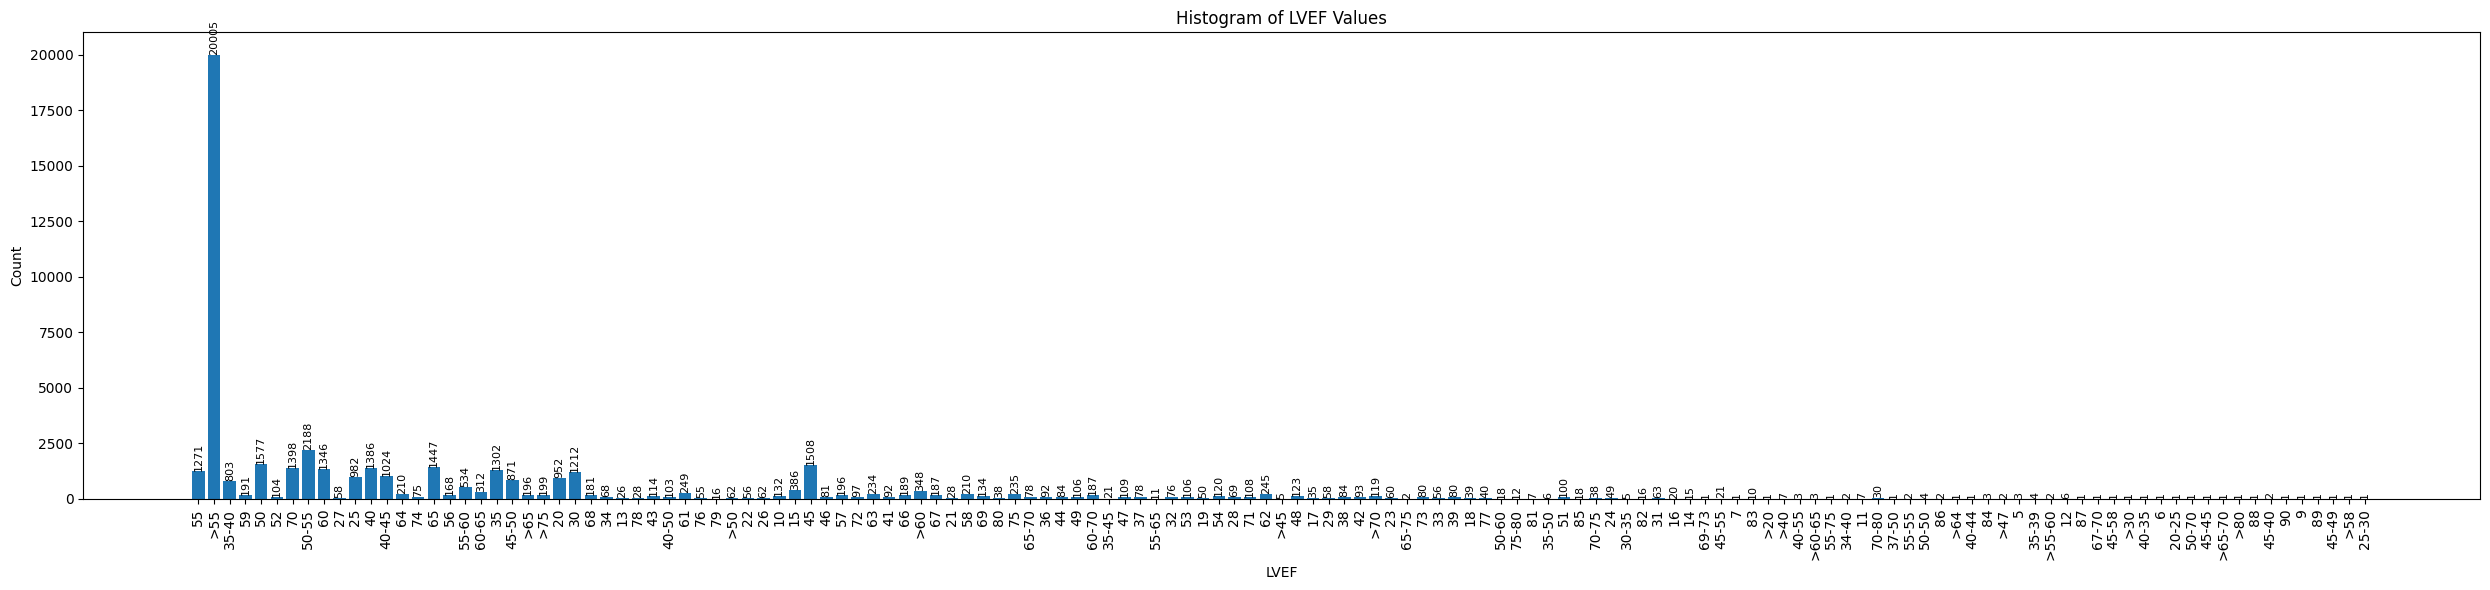

In [34]:
import matplotlib.pyplot as plt
from collections import Counter

# plot the histogram of counts of unique LVEF values
plt.figure(figsize=(25, 6))
lvef_counts = Counter(csv_filtered['lvef'])
plt.bar(lvef_counts.keys(), lvef_counts.values())
# write labels vertically
plt.xticks(rotation=90)
plt.xlabel('LVEF')
plt.ylabel('Count')
plt.title('Histogram of LVEF Values')
# put the number on top of the bar
for i, (key, value) in enumerate(lvef_counts.items()):
    plt.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
to_remove = ['>47', '50', ]

In [7]:
# get the row with specified subject ID
subject_id = 27897940
row = csv[csv['subject_id'] == subject_id]
print("Row for subject ID 10000764:")
print(row)

Row for subject ID 10000764:
Empty DataFrame
Columns: [subject_id, waveform_path, LVEF, class]
Index: []


In [5]:
tot_len = []
for sample in dataset:
    tot_len.append(sample['signal'].shape[0])

for sample in dataset_val:
    tot_len.append(sample['signal'].shape[0])

for sample in dataset_test:
    tot_len.append(sample['signal'].shape[0])

avg_len = np.array(tot_len).mean()
print('Average length:', (avg_len / 100))
tot_len = np.array(tot_len).sum()
tot_len = (tot_len / 100) / 3600
print('Total length:', tot_len)

Average length: 15.945000727696115
Total length: 30.432805555555557


In [6]:
import numpy as np
import pandas as pd

# load /media/Volume/data/DeepBeat_PPG/train.npz 

sample_train = np.load('/media/Volume/data/DeepBeat_PPG/train.npz', allow_pickle=True)
sample_val = np.load('/media/Volume/data/DeepBeat_PPG/validate.npz', allow_pickle=True)
sample_test = np.load('/media/Volume/data/DeepBeat_PPG/test.npz', allow_pickle=True)

# load as df
sample_train_df = pd.DataFrame(sample_train['parameters'])
sample_val_df = pd.DataFrame(sample_val['parameters'])
sample_test_df = pd.DataFrame(sample_test['parameters'])

In [7]:
sample_train_df.head()

uniques_1 = sample_train_df[1].unique()
print(uniques_1)

[' b' ' a' ' c' ' d' ' e' ' f' ' g' ' h']


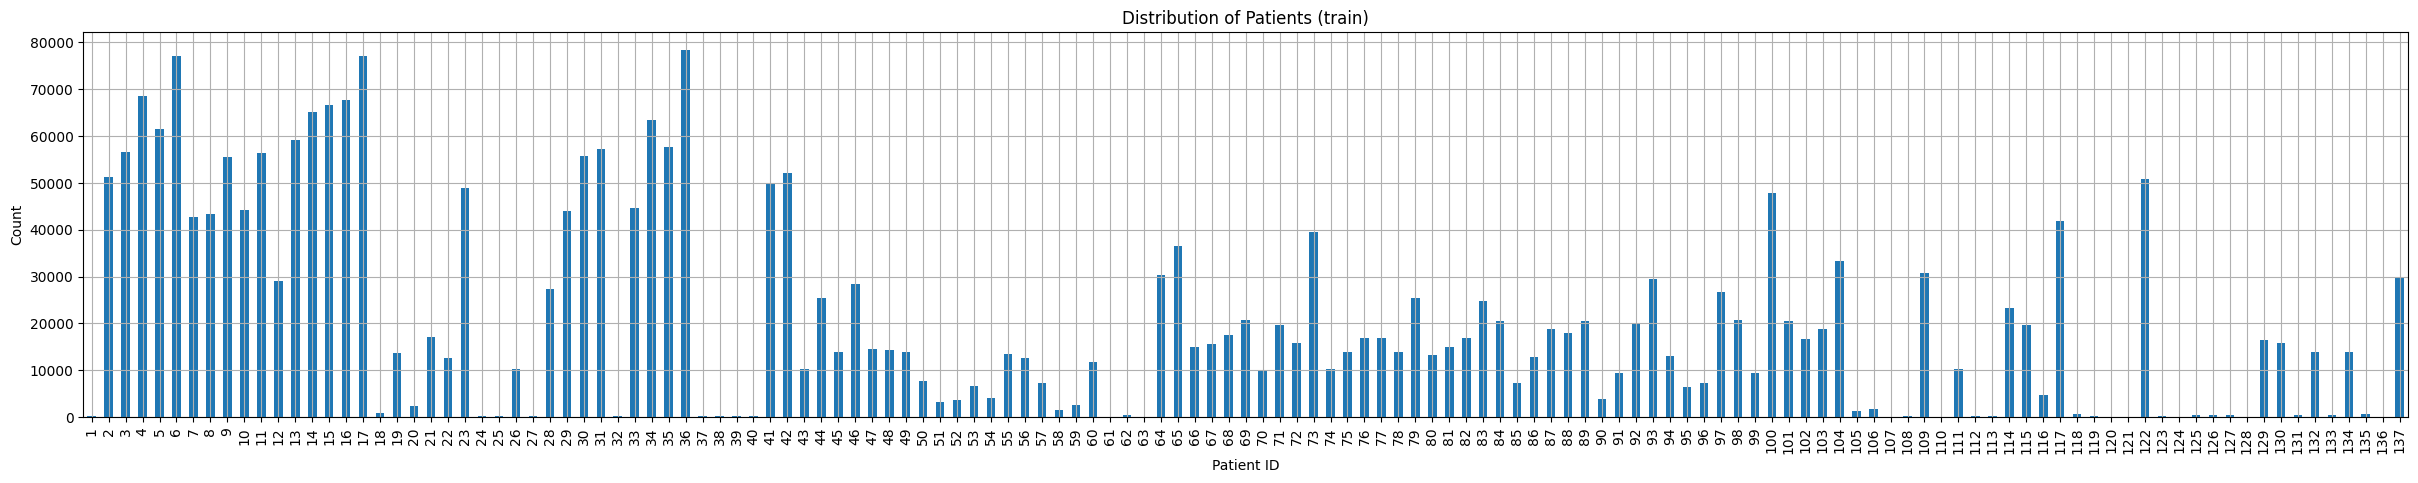

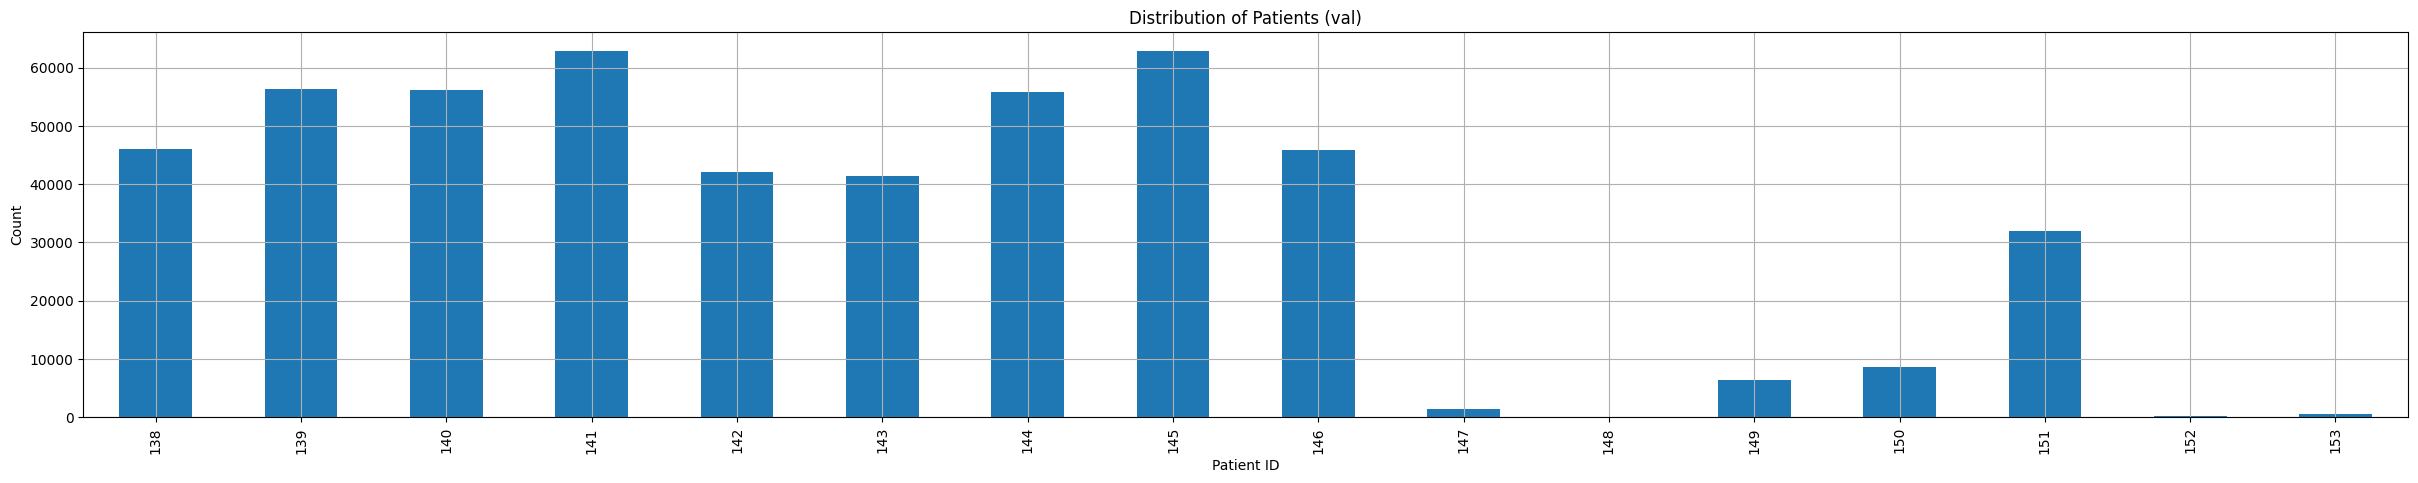

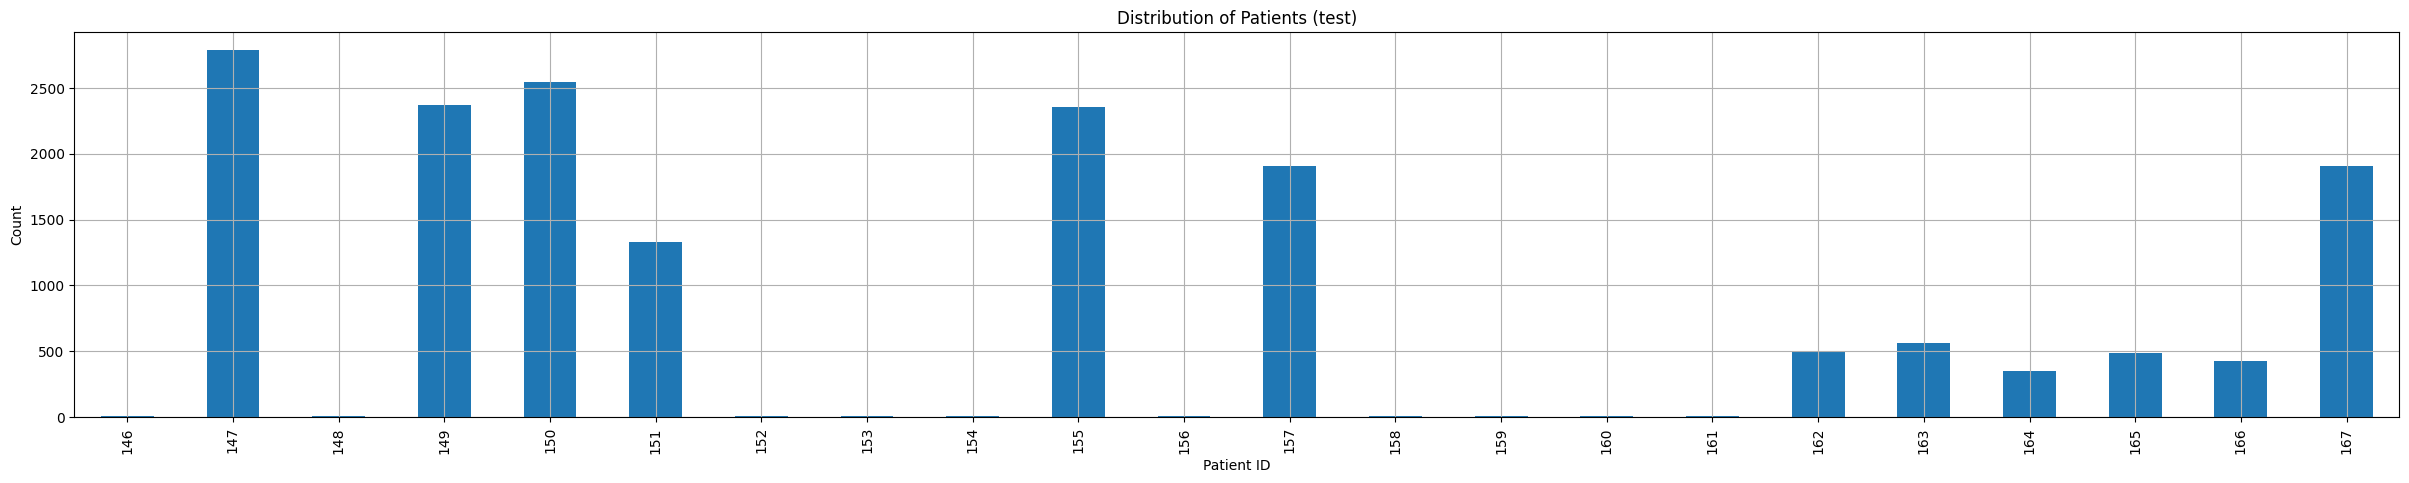

In [8]:
count_patients = sample_train_df[2].value_counts()
count_patients_val = sample_val_df[2].value_counts()
count_patients_test = sample_test_df[2].value_counts()
# order by index
count_patients = count_patients.sort_index()
count_patients_val = count_patients_val.sort_index()
count_patients_test = count_patients_test.sort_index()

# plot the distribution of patients
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 5))
count_patients.plot(kind='bar')
plt.title('Distribution of Patients (train)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_val.plot(kind='bar')
plt.title('Distribution of Patients (val)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_test.plot(kind='bar')
plt.title('Distribution of Patients (test)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()


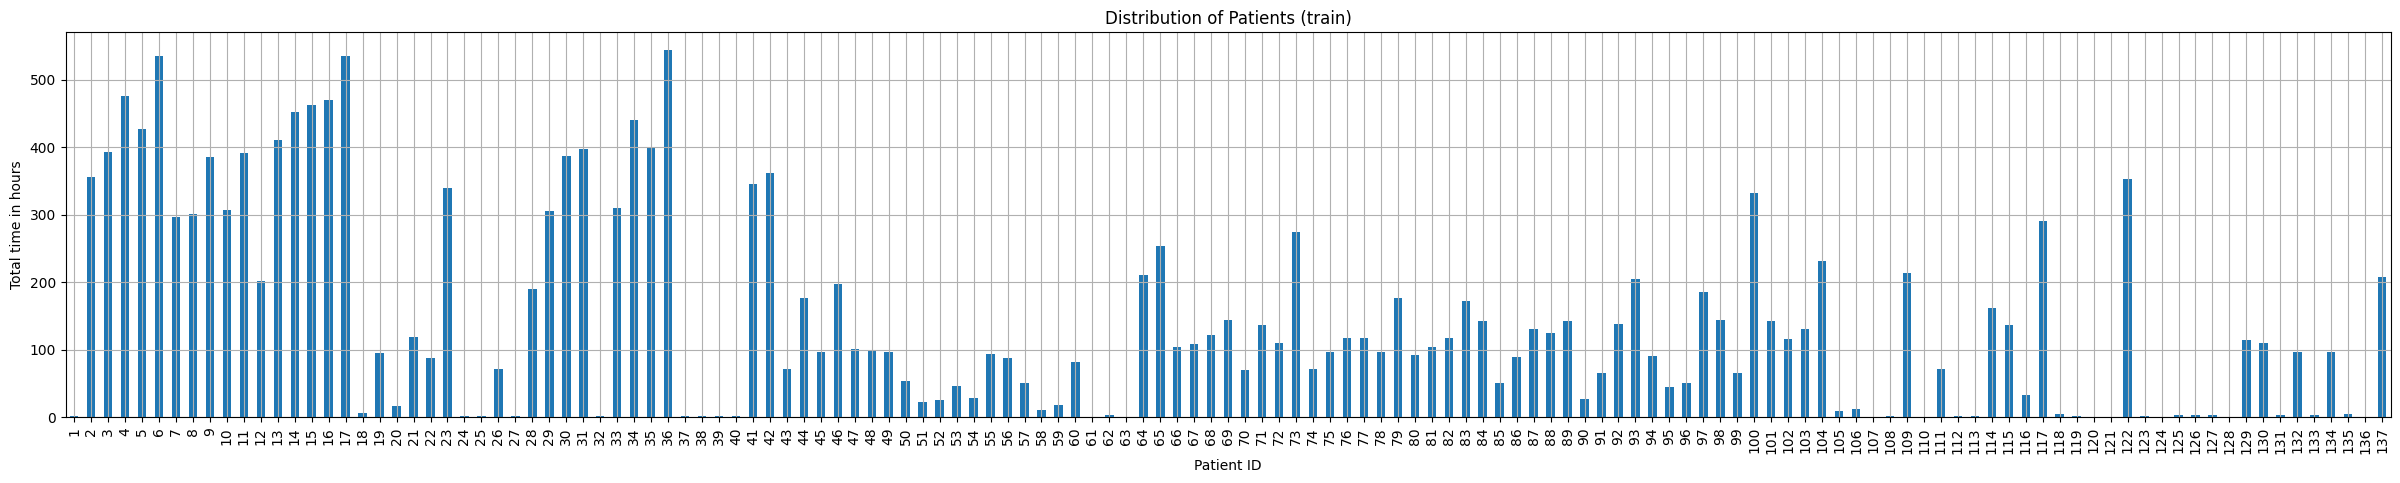

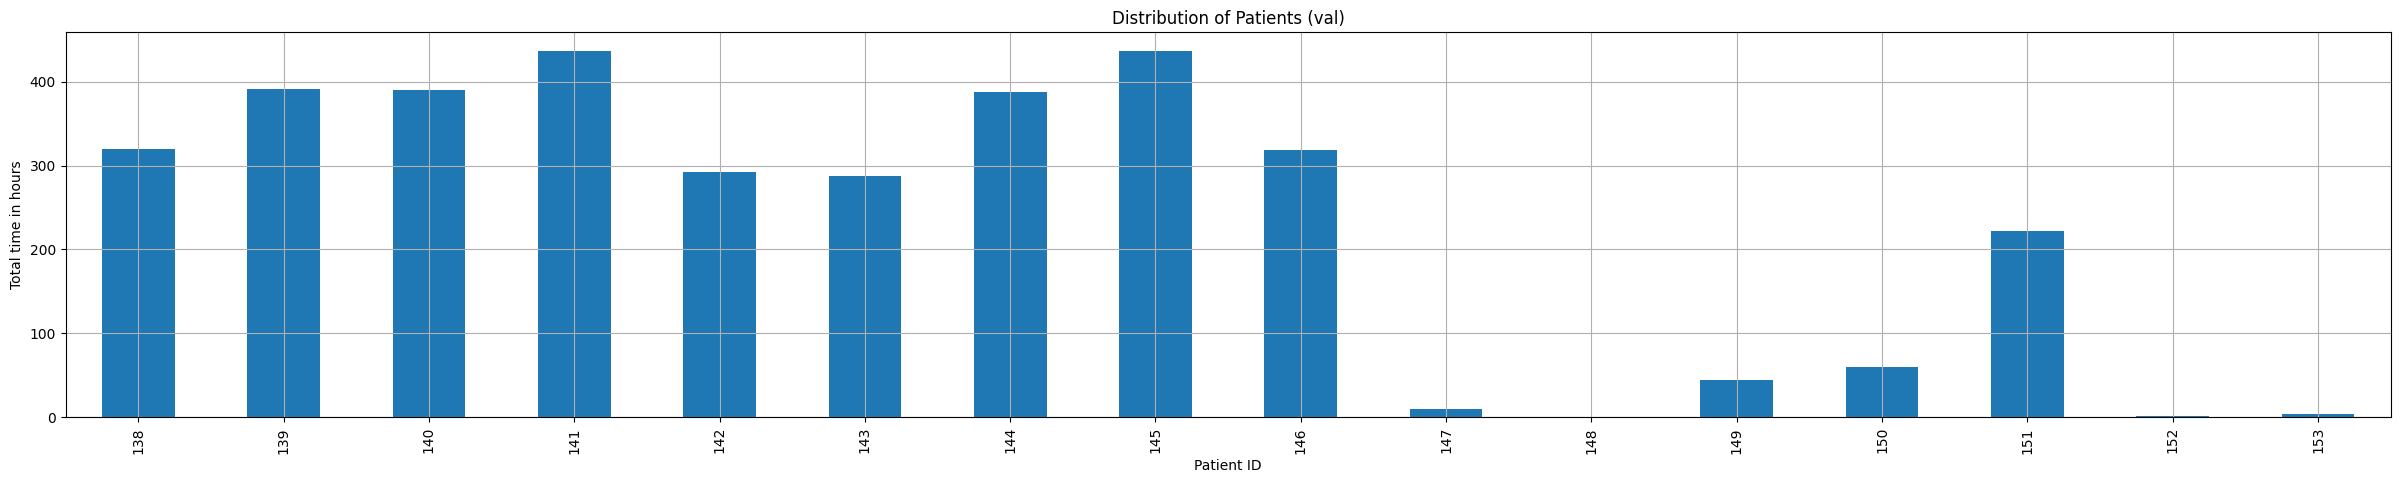

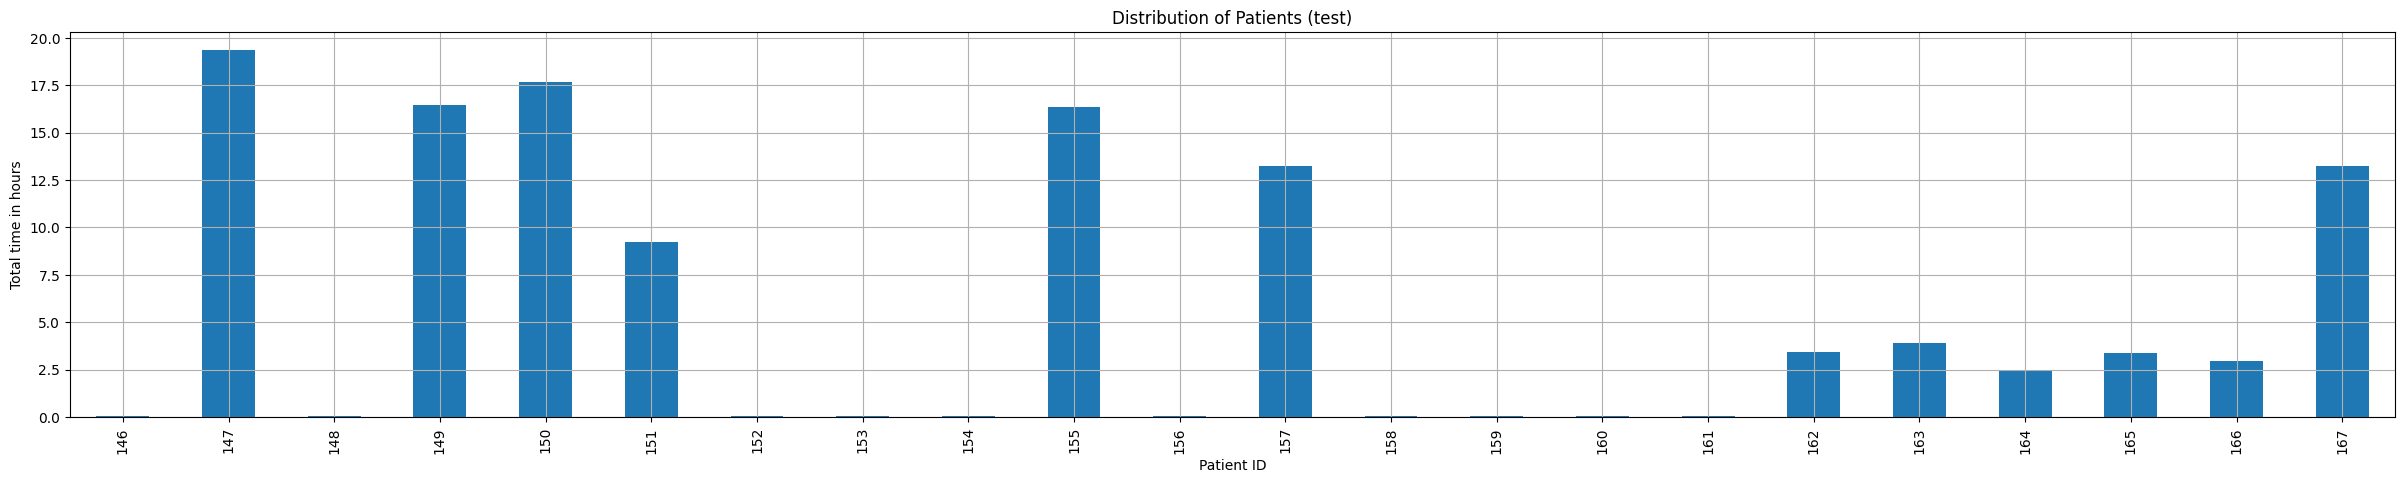

2
146       4.583333
147    1160.000000
148       4.583333
149     986.666667
150    1060.000000
151     553.333333
152       4.166667
153       3.333333
154       4.583333
155     980.000000
156       5.000000
157     795.000000
158       3.333333
159       5.000000
160       4.583333
161       3.750000
162     206.666667
163     233.333333
164     146.666667
165     204.166667
166     178.333333
167     793.333333
Name: count, dtype: float64
Average time in hours for train: 142.12966342254663
Average time in hours for val: 225.16579861111111
Average time in hours for test: 5.560921717171717


In [9]:
count_patients = sample_train_df[2].value_counts()
count_patients_val = sample_val_df[2].value_counts()
count_patients_test = sample_test_df[2].value_counts()
# order by index
count_patients = count_patients.sort_index() * 25 / 3600
count_patients_val = count_patients_val.sort_index() * 25 / 3600
count_patients_test = count_patients_test.sort_index() * 25 / 3600

# plot the distribution of patients
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 5))
count_patients.plot(kind='bar')
plt.title('Distribution of Patients (train)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_val.plot(kind='bar')
plt.title('Distribution of Patients (val)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_test.plot(kind='bar')
plt.title('Distribution of Patients (test)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

# print the smaller values of the test
print(count_patients_test * 60)
# print the average
print(f'Average time in hours for train: {count_patients.mean()}')
print(f'Average time in hours for val: {count_patients_val.mean()}')
print(f'Average time in hours for test: {count_patients_test.mean()}')


Index of patient 147 in test set: [4823, 4824, 4825, 4826, 4827, 4828, 4829, 4830, 4831, 4832, 4833, 4834, 4835, 4836, 4837, 4838, 4839, 4840, 4841, 4842, 4843, 4844, 4845, 4846, 4847, 4848, 4849, 4850, 4851, 4852, 4853, 4854, 4855, 4856, 4857, 4858, 4859, 4860, 4861, 4862, 4863, 4864, 4865, 4866, 4867, 4868, 4869, 4870, 4871, 4872, 4873, 4874, 4875, 4876, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884, 4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 4894, 4895, 4896, 4897, 4898, 4899, 4900, 4901, 4902, 4903, 4904, 4905, 4906, 4907, 4908, 4909, 4910, 4911, 4912, 4913, 4914, 4915, 4916, 4917, 4918, 4919, 4920, 4921, 4922, 4923, 4924, 4925, 4926, 4927, 4928, 4929, 4930, 4931, 4932, 4933, 4934, 4935, 4936, 4937, 4938, 4939, 4940, 4941, 4942, 4943, 4944, 4945, 4946, 4947, 4948, 4949, 4950, 4951, 4952, 4953, 4954, 4955, 4956, 4957, 4958, 4959, 4960, 4961, 4962, 4963, 4964, 4965, 4966, 4967, 4968, 4969, 4970, 4971, 4972, 4973, 4974, 4975, 4976, 4977, 4978, 4979, 4980, 4981, 4982, 4983,

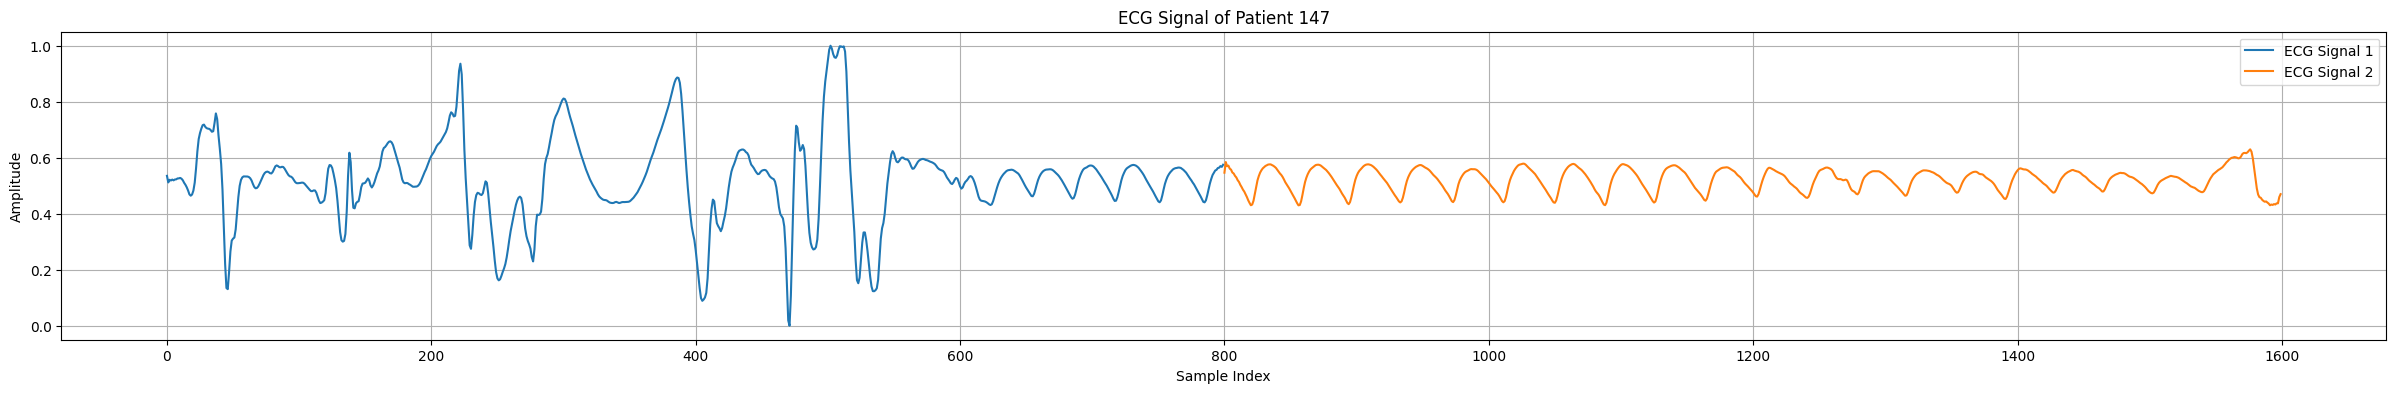

In [10]:
# get the index where patient is 147
index_147 = sample_test_df[sample_test_df[2] == 147].index
print(f'Index of patient 147 in test set: {index_147.to_list()}')

idx = 8
test_sample_1 = sample_test['signal'][index_147[idx]]
test_sample_2 = sample_test['signal'][index_147[idx + 1]] * 0.2 + 0.43

# plot the signal
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 4))
plt.plot(test_sample_1, label='ECG Signal 1')
plt.plot(np.arange(len(test_sample_1), len(test_sample_1) + len(test_sample_2)), test_sample_2, label='ECG Signal 2')
plt.legend()
plt.title('ECG Signal of Patient 147')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()

In [64]:
# print one sample
dataset = ECGCODE15Dataset(config, global_augmentations=get_transforms(config, split='train', type='global'), local_augmentations=get_transforms(config, split='train', type='local'))



using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
tabular data fields for CODE 15:           Unnamed: 0.1  Unnamed: 0  age  is_male  nn_predicted_age  1dAVb  \
exam_id                                                                    
1169160             0           0   38     True         40.160484  False   
2873686             1           1   73     True         67.059440  False   
168405              2           2   67     True         79.621740  False   
271011              3           3   41     True         69.750260  False   
384368              4           4   73     True         78.873460  False   

          RBBB   LBBB     SB     ST     AF  patient_id  death     timey  \
exam_id                                                                   
1169160  False  False  False  False  False      523632  False  2.098628   
2873686  False  False  False  False  False     1724173  False  6.657529   
168405   False  False  False  False   True 

Sample keys: dict_keys(['global_signals', 'local_signals'])
Global view 1 shape: torch.Size([921, 12])


/tmp/ipykernel_758458/1598727430.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=g1[:, 1], palette="tab10", legend=False)


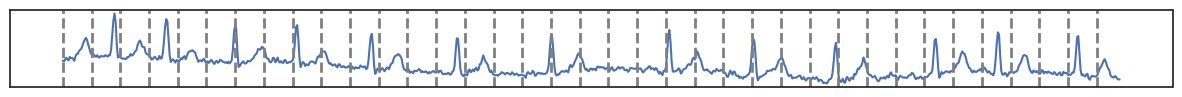

In [88]:
sample = dataset[9]
print("Sample keys:", sample.keys())
g1 = sample['global_signals'][0]
print("Global view 1 shape:", g1.shape)

# plot in a box with seaborn

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 1))
plt.tight_layout()
sns.lineplot(data=g1[:, 1], palette="tab10", legend=False)
# at every 25 timestep wrap in a box with sns
for i in range(0, g1.shape[0], 25):
    plt.axvline(x=i, color='gray', linestyle='--', linewidth=2)

plt.xticks([])
plt.yticks([])
#export to png
plt.savefig('figs/sample_global_view_1.png', bbox_inches='tight', dpi=300)

In [118]:
from dataset import generic_utils
import dataset.cpsc2018 as cpsc_utils

train_dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=config.num_workers, collate_fn=generic_utils.make_collate_fn(config), drop_last=True)
sample = train_dataloader.__iter__().__next__()
print(sample.keys())

dict_keys(['global_signals', 'local_signals'])


Global view 1 shape: torch.Size([4, 925, 12])
Global view 2 shape: torch.Size([4, 900, 12])


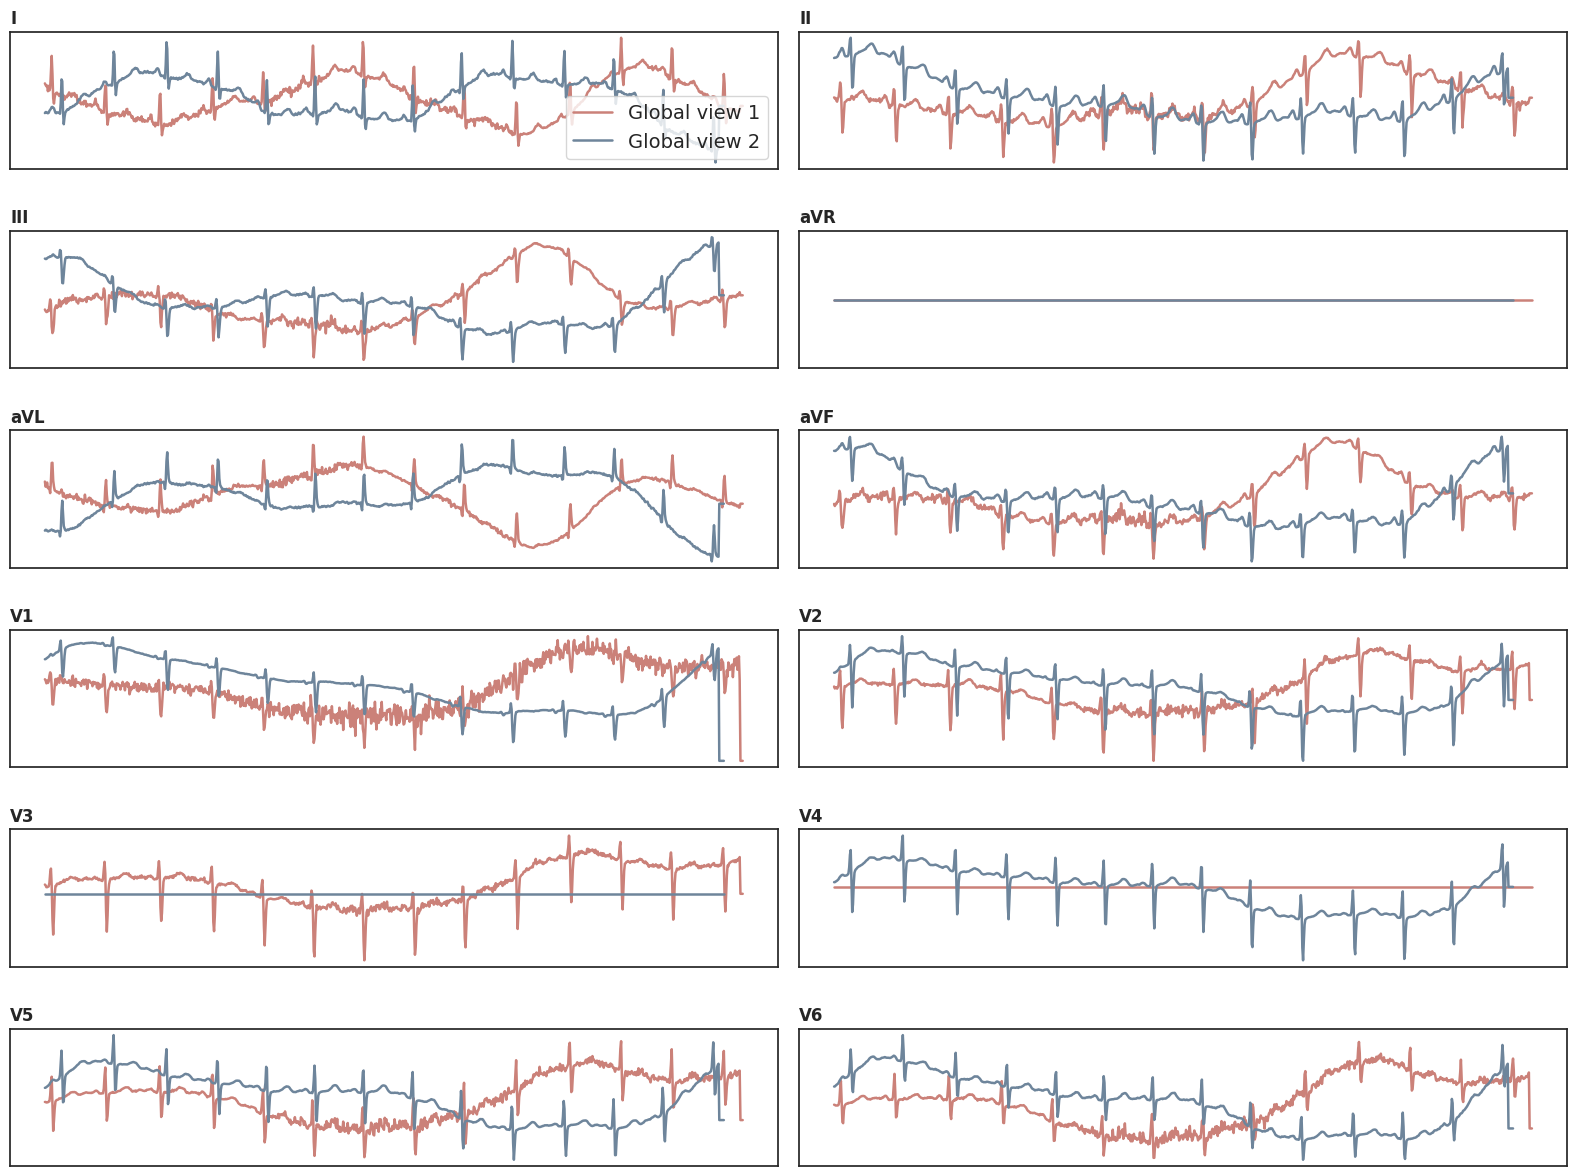

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a modern Seaborn style
sns.set(style="white", context="notebook", font_scale=1.2)

# Your list of ECG leads
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Create subplot grid: 6 rows x 2 columns
fig, axs = plt.subplots(6, 2, figsize=(16, 12))  # Adjust size for clarity

# Flatten axes array for easy indexing
axs = axs.flatten()

# Define colors
color_g1 = '#cb8179'  # warm tone
color_g2 = '#6e859b'  # cool tone

sample_g1 = sample['global_signals'][0] # Global view 1
sample_g2 = sample['global_signals'][1]  # Global view 2
print("Global view 1 shape:", sample_g1.shape)
print("Global view 2 shape:", sample_g2.shape)

# Loop over the 12 leads
for i in range(12):
    ax = axs[i]
    ax.plot(sample_g1[0, :, i], color=color_g1, label='Global view 1', linewidth=1.8)
    ax.plot(sample_g2[0, :, i], color=color_g2, label='Global view 2', linewidth=1.8)

    # Title
    ax.set_title(leads[i], fontsize=12, weight='bold', loc='left')

    # Remove ticks for a clean look
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove spines for minimalist style
    # for spine in ax.spines.values():
    #    spine.set_visible(False)

    # Add legend only once
    if i == 0:
        ax.legend(frameon=True, fontsize=14)

# Turn off unused subplot if needed (in case you have more than 12 axes)
for j in range(12, len(axs)):
    fig.delaxes(axs[j])

# Tight layout for cleaner spacing
plt.tight_layout(h_pad=2)

# Optional: add a global title
# fig.suptitle("ECG Lead Comparison — Global Views", fontsize=16, weight='bold', y=1.02)

plt.savefig('figs/ecg_lead_comparison_global_views.png', bbox_inches='tight', dpi=300)
plt.show()

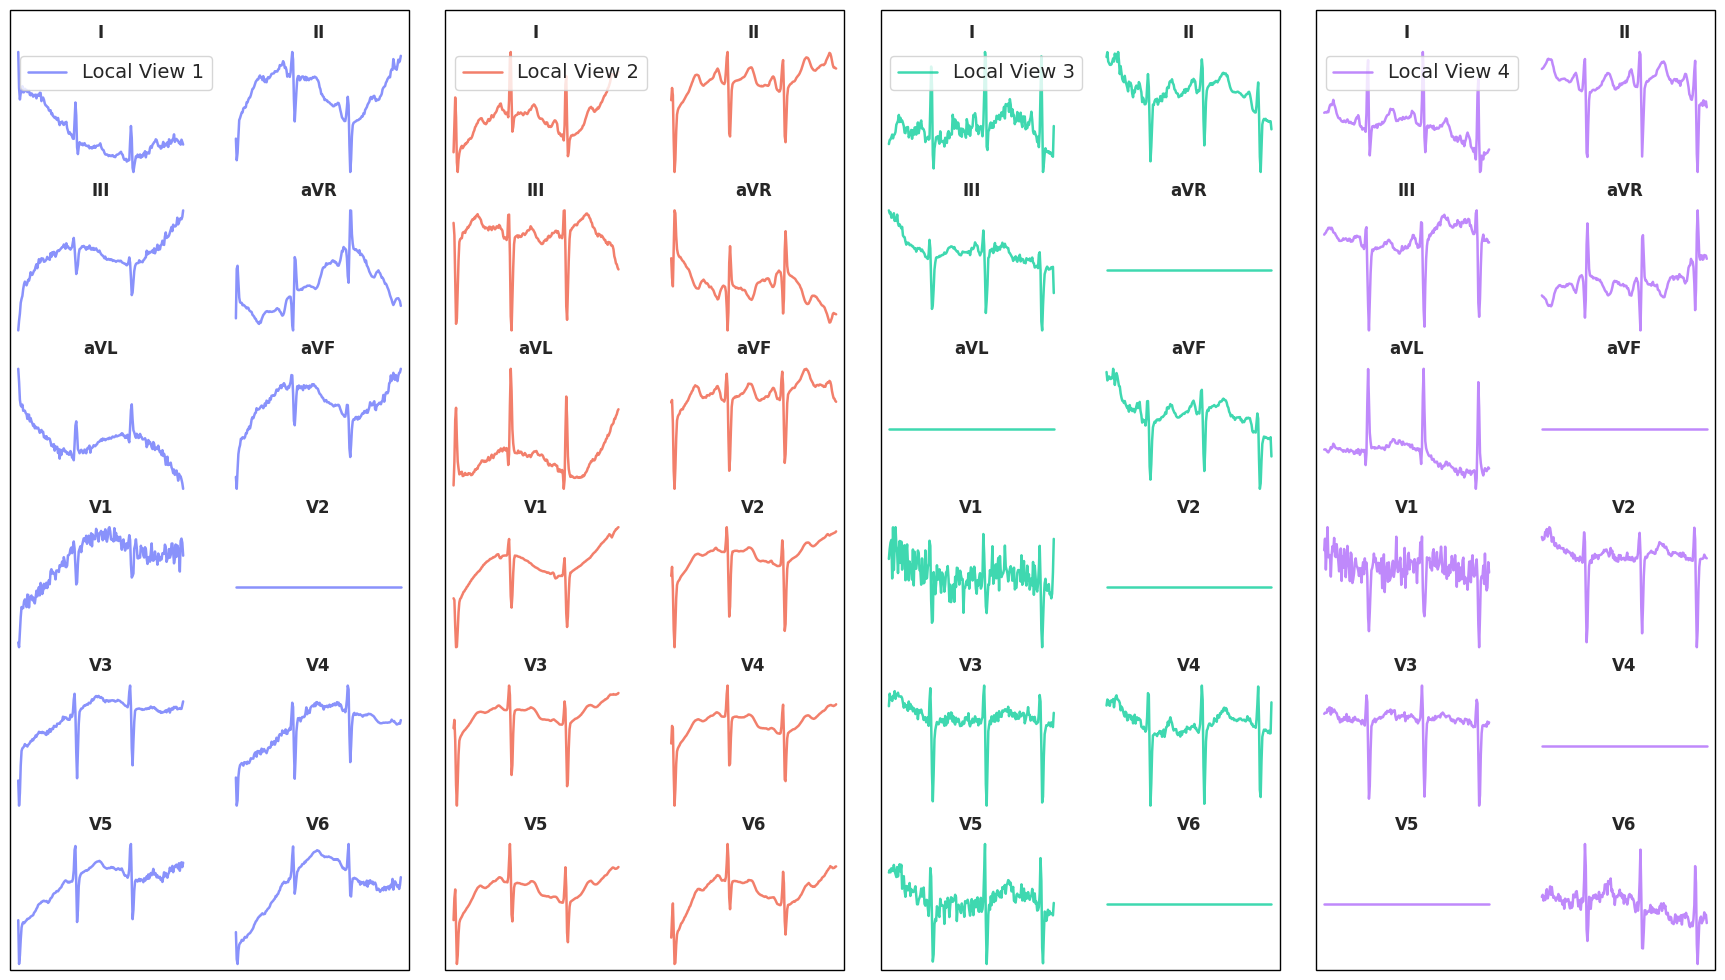

In [127]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from plotly.colors import qualitative

n_groups = 4
# --- Existing setup ---
fig, axs = plt.subplots(6, n_groups * 2, figsize=(22, 12))
axs = np.array(axs)
sample_idx = 0  # Index of the sample to plot
colors = qualitative.Plotly[:len(sample['local_signals'])]
colors = [f"{color}c0" for color in colors]  #
# Plotting signals
for j, g in enumerate(sample['local_signals']):
    for i in range(12):
        row = i // 2
        col = (i % 2) + j * 2
        ax = axs[row, col]
        ax.plot(g[sample_idx, :, i], color=colors[j], linewidth=1.8)

        # if row == 0:
        ax.set_title(leads[i], fontsize=12, weight='bold')

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # add legend only to the first column of each group
        if i == 0:
            ax.legend(
                [f'Local View {j+1}'],
                loc='upper left',
                fontsize=14,
                frameon=True,
                title_fontsize='12'
            )

# --- Fix rectangle positions ---
fig.canvas.draw()  # Important to get updated positions

for j in range(n_groups):
    ax_topleft = axs[0, j*2]
    ax_bottomright = axs[5, j*2+1]

    bbox1 = ax_topleft.get_position()
    bbox2 = ax_bottomright.get_position()

    # Slightly expand the rectangle bounds for better fit
    x0 = bbox1.x0
    y1 = bbox1.y1 + 0.03
    x1 = bbox2.x1 
    y0 = bbox2.y0 

    # Add background or border
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        transform=fig.transFigure,
        fill=False,  # change to True and add alpha for shading
        color='black',
        linewidth=1,
        zorder=1000  # ensure it's on top
    )
    fig.patches.append(rect)

    # Add title above group
    # fig.text(
    #    (x0 + x1) / 2, y1 + 0.01,
    #    f'Local View {j+1}',
    #    fontsize=12,
    #    ha='center',
    #    weight='bold'
    #)# 

# --- Layout ---
# plt.tight_layout(h_pad=1.5, w_pad=0.5)
# fig.suptitle("Local Signal Comparison Across Leads", fontsize=16, weight='bold', y=1.03)
plt.savefig('figs/local_signal_comparison_across_leads.png', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
import yaml
from dataset.generic_utils import get_transforms

from dataset.mit_bih import ECGMITBIHDataset
from utils.utils import parse_config

cfg = parse_config('configs/train_mit_bih_run_config.yaml', 'config_defaults/train_mit_bih_config_defaults.yaml')

dataset = ECGMITBIHDataset(cfg, split='val', augmentations=get_transforms(cfg, type='global', split='val'))

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


freq_factor: 1.3888888888888888, sampling_freq: 500, original_freq: 360


In [ ]:
sample = dataset[0]
print(sample.keys())
print(sample['r_peaks'])

import matplotlib.pyplot as plt

# plot the signal
plt.figure(figsize=(25, 5))
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def get_color(i):
    if i == 0:
        return 'red'
    elif i == 1:
        return 'blue'
    elif i == 2:
        return 'green'
    elif i == 3:
        return 'orange'
    elif i == 4:
        return 'purple'
    elif i == 5:
        return 'pink'
    else:
        return 'grey'
    
label = sample['label'].unsqueeze(0).unfold(1, cfg.patch_size, cfg.patch_size).max(dim=-1)[0].long().squeeze()
print(label.shape)
print(sample['signal'].shape)
    
plt.plot(sample['signal'][:, 1])

for j in range(0, len(sample['r_peaks']), cfg.patch_size):
    if sample['r_peaks'][j] != -1 and j // cfg.patch_size < len(label):
        # color the area between the r_peaks
        plt.axvspan(j, j+cfg.patch_size, color=get_color(label[j // cfg.patch_size]), alpha=0.2)


plt.show()

dict_keys(['signal', 'patient_id', 'r_peak', 'r_peak_orig'])


KeyError: 'r_peaks'

In [ ]:
from dataset.cpsc2018 import ECGCPSC2018Dataset
from utils.utils import parse_config
from dataset.generic_utils import get_transforms


cfg = parse_config('configs/train_cpsc2018_run_config.yaml', 'config_defaults/train_cpsc2018_defaults.yaml')

dataset = ECGCPSC2018Dataset(cfg, split='test', global_augmentations=get_transforms(cfg, type='global', split='val'))

sample path CODE15: g7/A6001
loaded 877 records
loaded 9 labels
labels: ['284470004', '59118001', '270492004', '164884008', '426783006', '164931005', '164889003', '164909002', '429622005']


In [ ]:
label = sample['label'].unsqueeze(0).unfold(1, config.patch_size, config.patch_size).max(dim=-1)[0].long()
print(label.shape)
print(sample['label'].shape)
print(label)

torch.Size([1, 225])
torch.Size([7200])
tensor([[ 0,  0, -1,  0,  0, -1,  0, -1,  0, -1,  0, -1,  2, -1,  0, -1,  0,  0,
          0, -1, -1,  0, -1,  0,  2, -1, -1,  0,  0, -1,  0, -1,  0, -1,  0,  0,
         -1,  0,  0, -1,  0,  0,  0, -1,  0,  0, -1,  0,  2,  0, -1, -1,  0,  0,
         -1,  0,  0, -1,  0,  2, -1,  0,  0, -1, -1,  0, -1,  0,  0,  0, -1,  0,
         -1, -1,  0, -1,  2, -1,  0, -1,  0,  2,  2,  2, -1,  0, -1,  0, -1, -1,
          0,  0, -1,  0,  2, -1, -1,  0,  2, -1,  0, -1,  2,  2,  0, -1,  0,  2,
         -1,  0,  2, -1, -1,  0, -1,  0,  0, -1,  0,  0, -1,  0,  0, -1,  0, -1,
          0, -1,  0,  0, -1,  0,  0, -1,  0, -1, -1,  0,  2,  2,  0, -1,  0,  0,
         -1,  0, -1,  0, -1,  0, -1,  0, -1, -1,  0,  2, -1,  0, -1,  0, -1,  0,
          0, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0, -1,  0, -1,  0,  2,
          2,  2,  2, -1,  0,  2, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0, -1,
          0,  2,  2,  0, -1,  0, -1,  0,  0, -1,  0, -1,  0, -1,  0, 

In [ ]:
import yaml
from dataset.generic_utils import get_transforms

from dataset.sleep_apnea import ECGSleepApneaDataset
from utils.utils import parse_config

cfg = parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')

dataset = ECGSleepApneaDataset(cfg, split='train')

Loading samples: 100%|██████████| 31/31 [00:00<00:00, 125.47it/s]

ann shape: torch.Size([1660]) should match 1660.0
ann shape: torch.Size([280]) should match 280.0
ann shape: torch.Size([1680]) should match 1680.0
ann shape: torch.Size([120]) should match 120.0
ann shape: torch.Size([800]) should match 800.0
ann shape: torch.Size([280]) should match 280.0
ann shape: torch.Size([320]) should match 320.0
ann shape: torch.Size([540]) should match 540.0
ann shape: torch.Size([980]) should match 980.0
ann shape: torch.Size([1200]) should match 1200.0
ann shape: torch.Size([2320]) should match 2320.0
ann shape: torch.Size([720]) should match 720.0
ann shape: torch.Size([1960]) should match 1960.0
ann shape: torch.Size([1920]) should match 1920.0
ann shape: torch.Size([1760]) should match 1760.0
ann shape: torch.Size([2240]) should match 2240.0
ann shape: torch.Size([100]) should match 100.0
ann shape: torch.Size([2160]) should match 2160.0
ann shape: torch.Size([1440]) should match 1440.0
ann shape: torch.Size([2160]) should match 2160.0
ann shape: torch.S

In [ ]:
sample = dataset[0]
print(sample.keys())
print(sample['annotation'].shape)
print(sample['signal'].shape[0] / 25)


dict_keys(['signal', 'annotation'])
torch.Size([103920])
2400.0


In [ ]:
dataset_mit_test = ECGMITBIHDataset(DatasetArgs(), subset='test')
print('dataset_mit_test len:', len(dataset_mit_test))

dataset_val = ECGMITBIHDataset(DatasetArgs(), subset='val', random_shift=False)
print('dataset_mit_val len:', len(dataset_val))

dataset_mit = ECGMITBIHDataset(DatasetArgs(), random_shift=False)
print('dataset_mit len:', len(dataset_mit))

Processing patients: 100%|██████████| 22/22 [00:00<00:00, 44924.39it/s]


dataset_mit_test len: 1342


Processing patients: 100%|██████████| 2/2 [00:00<00:00, 4629.47it/s]

dataset_mit_val len: 122



Processing patients: 100%|██████████| 20/20 [00:00<00:00, 50870.88it/s]


dataset_mit len: 10552


In [ ]:
from dataset.mit_bih import collate_fn

train_dataloader = DataLoader(dataset_mit, batch_size=128, shuffle=True, num_workers=32, collate_fn=collate_fn)
val_dataloader = DataLoader(dataset_val, batch_size=128, shuffle=False, num_workers=32, collate_fn=collate_fn)
test_dataloader = DataLoader(dataset_mit_test, batch_size=128, shuffle=False, num_workers=32, collate_fn=collate_fn)

# sanity check  
batch_train = next(iter(train_dataloader))  
print('batch_train len:', len(batch_train))
print('batch_train keys:', batch_train.keys())

batch_val = next(iter(val_dataloader))
print('batch_val len:', len(batch_val))
print('batch_val keys:', batch_val.keys())

batch_test = next(iter(test_dataloader))
print('batch_test len:', len(batch_test))
print('batch_test keys:', batch_test.keys())

batch_train len: 5
batch_train keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])
batch_val len: 5
batch_val keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])
batch_test len: 5
batch_test keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])


In [ ]:
import torch

def banded_tril_mask_indices(length: int, n: int) -> torch.Tensor:
    """
    Generates a len x len boolean mask where elements (row, col) are True
    iff row >= col AND row - col < n. This creates a lower triangular
    band starting from the main diagonal with width n.

    Args:
        length: The total size of the square matrix (len x len).
        n: The width of the band (number of diagonals including the main one).
           n=1 gives the main diagonal, n=2 gives main and first sub-diagonal, etc.

    Returns:
        A torch.Tensor of shape (length, length) and dtype torch.bool.
    """
    if not isinstance(length, int) or length <= 0:
        raise ValueError("length must be a positive integer")
    if not isinstance(n, int) or n <= 0:
        # n=0 would result in an all-False matrix, handled implicitly,
        # but usually n>=1 is intended for this pattern.
        raise ValueError("n (band width) must be a positive integer")

    # Create row and column indices
    rows = torch.arange(length).unsqueeze(1) # Shape: (length, 1)
    cols = torch.arange(length).unsqueeze(0) # Shape: (1, length)

    # Broadcasting creates (length, length) comparison tensors
    on_or_below_diag = rows >= cols
    within_band = (rows - cols) < n  # Difference is 0, 1, ..., n-1

    # Combine conditions using logical AND
    mask = on_or_below_diag & within_band

    return mask

# Example Usage
length = 5
n = 3 # Main diagonal (0), 1st sub-diag (1), 2nd sub-diag (2)
mask1 = banded_tril_mask_indices(length, n)
print("Method 1 (Indices):")
print(mask1)
# Expected Output:
# tensor([[ True, False, False, False, False],
#         [ True,  True, False, False, False],
#         [ True,  True,  True, False, False],
#         [False,  True,  True,  True, False],
#         [False, False,  True,  True,  True]])

length = 6
n = 4
mask1_large = banded_tril_mask_indices(length, n)
print("\nMethod 1 (Indices) - Larger Example (n=4):")
print(mask1_large)
# Expected Output:
# tensor([[ True, False, False, False, False, False],
#         [ True,  True, False, False, False, False],
#         [ True,  True,  True, False, False, False],
#         [ True,  True,  True,  True, False, False],
#         [False,  True,  True,  True,  True, False],
#         [False, False,  True,  True,  True,  True]])

Method 1 (Indices):
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [False,  True,  True,  True, False],
        [False, False,  True,  True,  True]])

Method 1 (Indices) - Larger Example (n=4):
tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False],
        [False,  True,  True,  True,  True, False],
        [False, False,  True,  True,  True,  True]])


In [ ]:
import torch

def banded_tril_mask_indices(length: int, n: int) -> torch.Tensor:
    """
    Generates the banded lower triangular mask from the previous step.
    Elements (row, col) are True iff row >= col AND row - col < n.
    """
    if not isinstance(length, int) or length <= 0:
        raise ValueError("length must be a positive integer")
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n (band width) must be a positive integer")
    rows = torch.arange(length).unsqueeze(1)
    cols = torch.arange(length).unsqueeze(0)
    on_or_below_diag = rows >= cols
    within_band = (rows - cols) < n
    return on_or_below_diag & within_band

def keep_first_true_per_row(input_mask: torch.Tensor) -> torch.Tensor:
    """
    Creates a new mask where only the first 'True' element in each row
    of the input_mask is set to 'True'. If a row has no 'True' elements,
    the corresponding output row will be all 'False'.

    Args:
        input_mask: The input boolean tensor (2D).

    Returns:
        A new boolean tensor with only the first True per row preserved.
    """
    if input_mask.dim() != 2:
        raise ValueError("Input mask must be 2D")

    # Find the index of the first True (max value = 1) in each row.
    # Use .int() or .float() as argmax works on numerical types.
    # Note: argmax returns 0 for rows that are all False.
    first_true_indices = torch.argmax(input_mask.int(), dim=1)

    # Create an output mask initialized to False
    output_mask = torch.zeros_like(input_mask, dtype=torch.bool)

    # Identify rows that actually contain at least one True
    # This is crucial to handle rows that were all False in the input
    rows_with_true = torch.any(input_mask, dim=1)

    # Get the row indices where we need to set a True value
    valid_row_indices = torch.where(rows_with_true)[0]

    # If there are no rows with True at all, return the all-False mask
    if len(valid_row_indices) == 0:
        return output_mask

    # Select the corresponding first_true_indices ONLY for these valid rows
    valid_first_true_indices = first_true_indices[valid_row_indices]

    # Use advanced indexing to set only the first True element in valid rows
    output_mask[valid_row_indices, valid_first_true_indices] = True

    return output_mask

# --- Generate the starting mask (banded lower triangular) ---
length = 6
n_band = 3
original_mask = banded_tril_mask_indices(length, n_band)

print("Original Banded Mask:")
print(original_mask)
# Expected:
# tensor([[ True, False, False, False, False],
#         [ True,  True, False, False, False],
#         [ True,  True,  True, False, False],
#         [False,  True,  True,  True, False],
#         [False, False,  True,  True,  True]])

# --- Apply the rule to keep only the first True per row ---
final_mask = keep_first_true_per_row(original_mask)

print("\nFinal Mask (First True per Row):")
print(final_mask)


Original Banded Mask:
tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [False,  True,  True,  True, False, False],
        [False, False,  True,  True,  True, False],
        [False, False, False,  True,  True,  True]])

Final Mask (First True per Row):
tensor([[ True, False, False, False, False, False],
        [ True, False, False, False, False, False],
        [ True, False, False, False, False, False],
        [False,  True, False, False, False, False],
        [False, False,  True, False, False, False],
        [False, False, False,  True, False, False]])


In [ ]:
import torch

bs, seq_len, emb_size = 2, 5, 3  # for instance

x = torch.arange(bs * seq_len * emb_size).reshape(bs, seq_len, emb_size)
print('x:', x)

loopback = 4
causal_mask = banded_tril_mask_indices(seq_len, loopback)  # shape [seq_len, seq_len]
causal_idx = keep_first_true_per_row(causal_mask)  # shape [seq_len, seq_len]
print('causal_idx:', causal_idx)
print('causal_mask:', causal_mask)

causal_mask = causal_mask.unsqueeze(0).unsqueeze(-1)  # now shape [1, seq_len, seq_len, 1]
x_expanded = x.unsqueeze(1).expand(bs, seq_len, seq_len, emb_size)
# print('x_expanded:', x_expanded)

x_causal = x_expanded.masked_fill(~causal_mask, 0)
print('x_causal:', x_causal)
x_causal = x_causal.reshape(bs * seq_len, seq_len, emb_size)
# x_causal = x_causal.flip(1)
print('x_causal flipped:', x_causal)
x = x_causal.reshape(bs, seq_len, seq_len, emb_size)
x = x[:, causal_idx, :]

print('x:', x)

x: tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11],
         [12, 13, 14]],

        [[15, 16, 17],
         [18, 19, 20],
         [21, 22, 23],
         [24, 25, 26],
         [27, 28, 29]]])
causal_idx: tensor([[ True, False, False, False, False],
        [ True, False, False, False, False],
        [ True, False, False, False, False],
        [ True, False, False, False, False],
        [False,  True, False, False, False]])
causal_mask: tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [False,  True,  True,  True,  True]])
x_causal: tensor([[[[ 0,  1,  2],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0]],

         [[ 0,  1,  2],
          [ 3,  4,  5],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0]],

         [[ 0,  1,  2],
        

In [ ]:
from matplotlib.widgets import Slider
from ipywidgets import interact

pat_id = dataset_mit.patients[-2]
print('pat_id:', pat_id)
# pat_id = 202
patient = dataset_mit.signals[pat_id][:, 0]
header = dataset_mit.headers[pat_id]
annotations = dataset_mit.annotations[pat_id]
# print(annotations.__dict__)

def convert_label(symbol):
    """
    Convert the symbols to the main class label
    """
    if symbol in ['N', 'L', 'R', 'e', 'j']:
        return 'N'
    elif symbol in ['A', 'a', 'J', 'S']:
        return 'S'  # Supraventricular ectopic
    elif symbol in ['V', 'E']:
        return 'V'  # Ventricular ectopic
    elif symbol in ['F']:
        return 'F'  # Fusion
    elif symbol in ['/', 'f', 'Q']:
        return 'Q'  # Unknown
    else:
        print(symbol)
        raise (f'Unknown symbol {symbol}')
    
def int_to_label(val):
    if val == 0:
        return 'N'
    elif val == 1:
        return 'S'
    elif val == 2:
        return 'V'
    elif val == 3:
        return 'F'
    elif val == 4:
        return 'Q'
    else:
        raise (f'Unknown label {val}')
    
valid_annotations = set(['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q'])

r_peaks = annotations.sample
r_peaks = [r_peak for i, r_peak in enumerate(r_peaks) if annotations.symbol[i] in valid_annotations]

labels_orig = [label for label in annotations.symbol if label in valid_annotations]
labels = [convert_label(l) for l in labels_orig]


import matplotlib.pyplot as plt

def plot_scrollable(start):
    end = start + 10000
    plt.figure(figsize=(30, 4))
    plt.plot(patient)
    plt.xlim(start, end)
    
    # Convert x-axis ticks to seconds
    #plt.xticks(
    #    ticks=range(start, end, 3600),  # 360 samples per second, so 3600 for 10-second intervals
    #    labels=[f"{x/360:.1f}s" for x in range(start, end, 3600)]
    #)
    
    # Add labels at r_peak positions
    for r_peak, label, orig in zip(r_peaks, labels, labels_orig):
        if start <= r_peak < end:
            plt.text(r_peak, patient[r_peak], label, color='red', fontsize=12, ha='center', va='bottom')
            plt.text(r_peak, patient[r_peak], orig, color='blue', fontsize=12, ha='center', va='top')
    plt.show()

interact(plot_scrollable, start=(0, len(patient) - 1000, 8000))


pat_id: 223


interactive(children=(IntSlider(value=320000, description='start', max=649000, step=8000), Output()), _dom_cla…

<function __main__.plot_scrollable(start)>

10552
r_peaks shape: torch.Size([9360])
labels shape: torch.Size([9360])


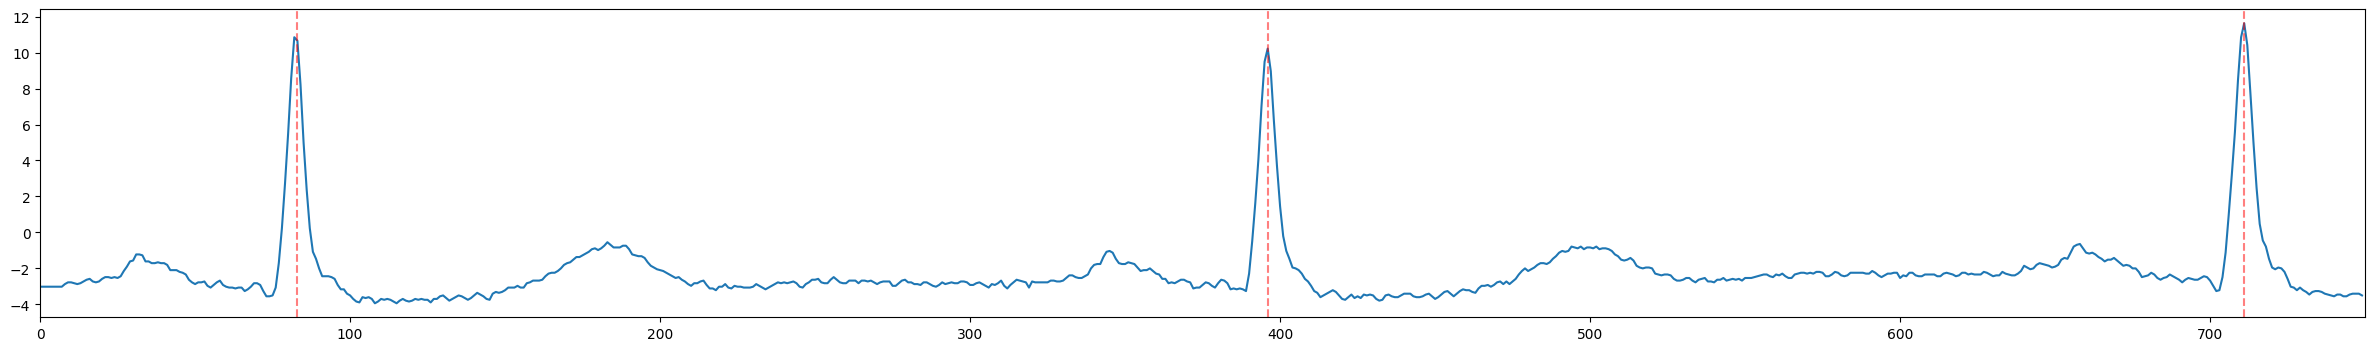

In [ ]:
print(len(dataset_mit))
sample = dataset_mit[1]

print('r_peaks shape:', sample['r_peaks'].shape)
print('labels shape:', sample['label'].shape) 


# plot sample and labels

def plot_sample(sample, start, end):
    plt.figure(figsize=(30, 4))
    signal = sample['signal'][start:end, 1]
    plt.plot(signal.numpy())
    plt.xlim(0, len(signal))
    
    # Convert x-axis ticks to seconds
    #plt.xticks(
    #    ticks=range(0, len(signal), 3600),  # 360 samples per second, so 3600 for 10-second intervals
    #    labels=[f"{x/360:.1f}s" for x in range(0, len(signal), 3600)]
    #)

    # add a red dotted vertical line when the r_peaks is 1
    for i, r_peak in enumerate(sample['r_peaks']):
        if r_peak == 1 and i < end and i >= start:
            plt.axvline(x=i - start, color='red', linestyle='--', alpha=0.5)

    # add a blue dotted vertical line when the label is not -1
    #for i, label in enumerate(sample['label']):
    #    if label != -1 and i < end and i >= start:
    #        plt.axvline(x=i - start, color='blue', linestyle='--')
    #        lolz = int_to_label(int(label))
    #        # plt.text(i - start, 0, str(lolz), color='blue', fontsize=12, ha='center', va='bottom')

plot_sample(sample, 0, 750)

In [ ]:
from utils.train_utils import patch_target_pointwise
from dataset.mit_bih import collate_fn

dataloader = DataLoader(dataset_mit, batch_size=10, shuffle=True, collate_fn=collate_fn)

print('len dataloader:', len(dataloader))

batch = next(iter(dataloader))
# print('batch:', batch)
print('label shape:', batch['label'].shape) # [bs, num_leads, seq_len]  
#print('targets', batch['label'])
#print('targes[0]:', batch['label'][0][512:768])

targets = patch_target_pointwise(batch['label'], patch_size=64, ignore_index=-1) # [bs, num_patch]
#print('targets shape:', targets.shape)
#print('targets:', targets)
#print('targets[0]:', targets[0])

patch_size = 64
t = batch['label'].unfold(1, patch_size, patch_size).max(dim=-1)[0]
print('t shape:', t.shape) # [bs, num_leads, num_patches, patch_size]
print('t:', t)
print('t[0]:', t[3])

signal = batch['signal']

import models.modules as modules
enriched_emb = modules.EnrichedLinearPatchEmbedding(
    num_channels=12,
    num_hiddens=512,
    patch_size=64,
).to('cuda')

x = enriched_emb(signal.permute(0,2,1).to('cuda'))
print('x shape:', x.shape) # [bs, num_patches, num_hiddens]


len dataloader: 337
label shape: torch.Size([10, 10800])
t shape: torch.Size([10, 168])
t: tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ...,  0., -1., -1.],
        [-1., -1., -1.,  ...,  0., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]])
t[0]: tensor([-1., -1., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1., -1., -1.,  0.,
        -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,
        -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,
         0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,
         0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,

In [115]:
import pandas as pd
import numpy as np
import dask.dataframe as dd

# Load the labevents.csv.gz file using Dask
labevent = dd.read_csv('/media/Volume/data/MIMIC_IV/labevents.csv.gz')
print(labevent.head())

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/dask/dataframe/io/csv.py:508: UserWarning: Warning gzip compression does not support breaking apart files
Please ensure that each individual file can fit in memory and
use the keyword ``blocksize=None to remove this message``
Setting ``blocksize=None``
  warn(


: 

In [112]:
labitem = pd.read_csv('/media/Volume/data/MIMIC_IV/d_labitems.csv.gz')
# get item id corresponding to NT-proBNP
nt_pro_bnp= labitem[labitem['label'].str.contains('NTpro', na=False)]
print("NT-proBNP item ID:", nt_pro_bnp)
nt_pro_bnp_id = nt_pro_bnp['itemid'].values[0]
print("NT-proBNP item ID:", nt_pro_bnp_id)

NT-proBNP item ID:      itemid     label  fluid   category
160   50963  NTproBNP  Blood  Chemistry
NT-proBNP item ID: 50963


Number of NT-proBNP events: 98206
      subject_id  itemid            charttime value  valuenum valueuom
3216    10000690   50963  2150-07-02 23:30:00   ___    1489.0    pg/mL
3376    10000690   50963  2150-09-16 16:15:00   ___    2600.0    pg/mL
3649    10000690   50963  2150-11-02 12:10:00   ___    3940.0    pg/mL
3967    10000690   50963  2152-01-28 16:10:00   ___   17722.0    pg/mL
6659    10000935   50963  2187-10-11 06:25:00   ___     617.0    pg/mL
Unique units of measurement for NT-proBNP: ['pg/mL']


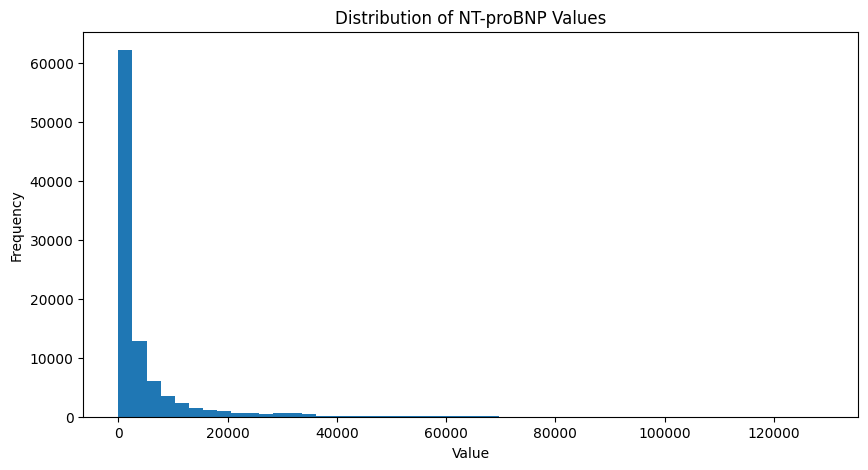

In [113]:
# filter the labevent dataframe for NT-proBNP
nt_pro_bnp_events = labevent[labevent['itemid'] == nt_pro_bnp_id]
print("Number of NT-proBNP events:", len(nt_pro_bnp_events))
# print the first few rows
print(nt_pro_bnp_events.head())

# get unique valueuom
unique_uoms = nt_pro_bnp_events['valueuom'].unique()
print("Unique units of measurement for NT-proBNP:", unique_uoms)

# plot values distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
nt_pro_bnp_events['valuenum'].dropna().hist(bins=50)
plt.title('Distribution of NT-proBNP Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [91]:
patient_id_list = nt_pro_bnp_events['subject_id'].unique()
print("Number of unique patients with NT-proBNP events:", len(patient_id_list))
print("Number of NT-proBNP events per patient:", len(nt_pro_bnp_events['subject_id']))

Number of unique patients with NT-proBNP events: 115634
Number of NT-proBNP events per patient: 459872


In [92]:
ecgs_raw = pd.read_csv('/media/Volume/data/MIMIC_IV/exams_filtered.csv')
print(ecgs_raw.head())

   Unnamed: 0                                 file_name  study_id  subject_id  \
0           0  files/p1000/p10000032/s40689238/40689238  40689238    10000032   
1           1  files/p1000/p10000032/s44458630/44458630  44458630    10000032   
2           2  files/p1000/p10000032/s49036311/49036311  49036311    10000032   
3           3  files/p1000/p10000117/s45090959/45090959  45090959    10000117   
4           4  files/p1000/p10000117/s48446569/48446569  48446569    10000117   

              ecg_time  ed_stay_id  ed_hadm_id  hosp_hadm_id  \
0  2180-07-23 08:44:00  39399961.0  29079034.0           NaN   
1  2180-07-23 09:54:00  39399961.0  29079034.0           NaN   
2  2180-08-06 09:07:00         NaN         NaN    25742920.0   
3  2181-03-04 17:14:00         NaN         NaN           NaN   
4  2183-09-18 13:52:00  33176849.0  27988844.0           NaN   

               ed_diag_ed                                       ed_diag_hosp  \
0      ['R4182', 'G9340']  ['F319', 'J449', 'B18

In [93]:
# read first line of the csv via readlines
with open('/media/Volume/data/MIMIC_IV/exams_filtered.csv', 'r') as file:
    first_line = file.readline().strip()
    second_line = file.readline().strip()
print("First line of exams_filtered.csv:", first_line)
print("Second line of exams_filtered.csv:", second_line)

First line of exams_filtered.csv: ,file_name,study_id,subject_id,ecg_time,ed_stay_id,ed_hadm_id,hosp_hadm_id,ed_diag_ed,ed_diag_hosp,hosp_diag_hosp,all_diag_hosp,all_diag_all,gender,age,anchor_year,anchor_age,dod,ecg_no_within_stay,ecg_taken_in_ed,ecg_taken_in_hosp,ecg_taken_in_ed_or_hosp,fold,strat_fold
Second line of exams_filtered.csv: 0,files/p1000/p10000032/s40689238/40689238,40689238,10000032,2180-07-23 08:44:00,39399961.0,29079034.0,,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I9581', 'R188', 'Z21', 'Z66', 'F17200', 'E875', 'R64', 'K7469']",[],"['K7469', 'E871', 'R64', 'E875', 'I9581', 'J449', 'R188', 'V462', 'F17200', 'Z21', 'B182', 'F319', 'Z66']","['K7469', 'E871', 'R64', 'E875', 'I9581', 'J449', 'R188', 'V462', 'F17200', 'Z21', 'B182', 'F319', 'Z66']",F,52.0,2180.0,52.0,2180-09-09,0,True,False,True,17,9


In [94]:
# Filter to matching subjects
subject_set = set(nt_pro_bnp_events['subject_id']) & set(ecgs_raw['subject_id'])
lab_events = nt_pro_bnp_events[nt_pro_bnp_events['subject_id'].isin(subject_set)].copy()
ecgs = ecgs_raw[ecgs_raw['subject_id'].isin(subject_set)].copy()

# Convert to datetime
# Ensure datetime columns and drop missing
lab_events['charttime'] = pd.to_datetime(lab_events['charttime'])
ecgs['ecg_time'] = pd.to_datetime(ecgs['ecg_time'])

lab_events = lab_events.dropna(subset=['charttime'])
ecgs = ecgs.dropna(subset=['ecg_time'])

# Sort each DataFrame by subject_id and then by time strictly ascending within each subject
lab_events = lab_events.sort_values(['charttime'])
ecgs = ecgs.sort_values(['ecg_time'])

# Now merge_asof
merged = pd.merge_asof(
    ecgs,
    lab_events,
    by='subject_id',
    left_on='ecg_time',
    right_on='charttime',
    direction='nearest'
)

# keep only useful columns
print("Merged columns:", merged.columns)
merged = merged[['subject_id', 'study_id', 'ecg_time', 'charttime', 'valuenum', 'file_name', 'flag']]

# add column difference between ecg_time and charttime in timedelta format
merged['time_diff'] = (merged['ecg_time'] - merged['charttime'])

merged.head()

Merged columns: Index(['Unnamed: 0', 'file_name', 'study_id', 'subject_id', 'ecg_time',
       'ed_stay_id', 'ed_hadm_id', 'hosp_hadm_id', 'ed_diag_ed',
       'ed_diag_hosp', 'hosp_diag_hosp', 'all_diag_hosp', 'all_diag_all',
       'gender', 'age', 'anchor_year', 'anchor_age', 'dod',
       'ecg_no_within_stay', 'ecg_taken_in_ed', 'ecg_taken_in_hosp',
       'ecg_taken_in_ed_or_hosp', 'fold', 'strat_fold', 'labevent_id',
       'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime',
       'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower',
       'ref_range_upper', 'flag', 'priority', 'comments'],
      dtype='object')


,subject_id,study_id,ecg_time,charttime,valuenum,file_name,flag,time_diff
0,17623300,47226307,2099-04-11 13:37:00,2111-05-25 15:34:00,NaN,files/p1762/p17623300/s47226307/47226307,NaN,-4427 days +22:03:00
1,11348122,43615010,2100-01-01 10:13:00,2110-03-21 12:00:00,NaN,files/p1134/p11348122/s43615010/43615010,NaN,-3732 days +22:13:00
2,17623300,49544792,2100-04-16 13:48:00,2111-05-25 15:34:00,NaN,files/p1762/p17623300/s49544792/49544792,NaN,-4057 days +22:14:00
3,10003417,41473810,2100-06-17 14:44:00,2111-01-02 15:50:00,0.03,files/p1000/p10003417/s41473810/41473810,abnormal,-3852 days +22:54:00
4,10966847,45285295,2100-07-02 14:36:00,2110-01-20 11:38:00,NaN,files/p1096/p10966847/s45285295/45285295,NaN,-3489 days +02:58:00


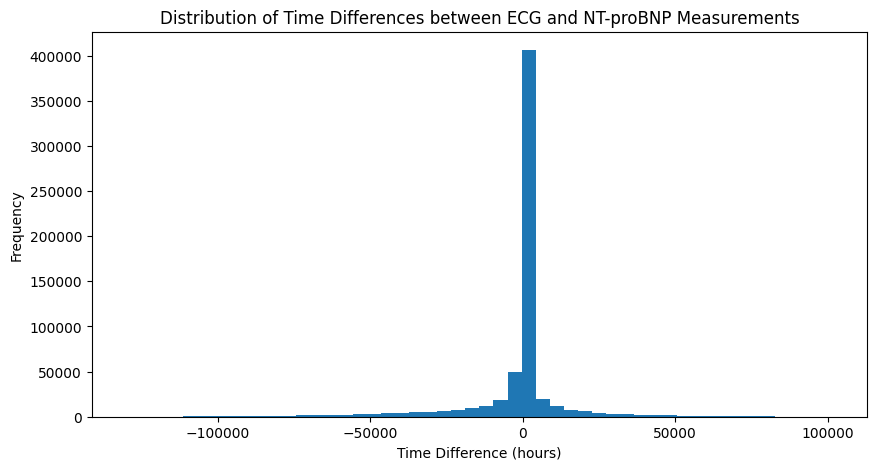

In [97]:
plt.figure(figsize=(10, 5))
merged['time_delta_hours'] = merged['time_diff'].dt.total_seconds() / 3600
merged['time_delta_hours'].dropna().hist(bins=50)
plt.title('Distribution of Time Differences between ECG and NT-proBNP Measurements')
plt.xlabel('Time Difference (hours)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [95]:
# keep oly rows where time_diff is less than 12 hour

merged_filtered = merged[merged['time_diff'].abs() < pd.Timedelta(hours=12)]
merged_filtered.head()

,subject_id,study_id,ecg_time,charttime,valuenum,file_name,flag,time_diff
341,15264462,42507952,2109-02-26 14:56:00,2109-02-26 16:25:00,NaN,files/p1526/p15264462/s42507952/42507952,NaN,-1 days +22:31:00
479,12024697,40396722,2110-01-09 11:40:00,2110-01-09 11:37:00,0.23,files/p1202/p12024697/s40396722/40396722,abnormal,0 days 00:03:00
482,12024697,45699330,2110-01-10 08:15:00,2110-01-10 03:17:00,0.19,files/p1202/p12024697/s45699330/45699330,abnormal,0 days 04:58:00
485,17195991,42031236,2110-01-11 21:49:00,2110-01-11 22:00:00,0.05,files/p1719/p17195991/s42031236/42031236,abnormal,-1 days +23:49:00
491,17195991,47290302,2110-01-15 14:37:00,2110-01-15 20:23:00,0.02,files/p1719/p17195991/s47290302/47290302,abnormal,-1 days +18:14:00


/tmp/ipykernel_85904/1950998143.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['time_delta_hours'] = merged_filtered['time_diff'].dt.total_seconds() / 3600


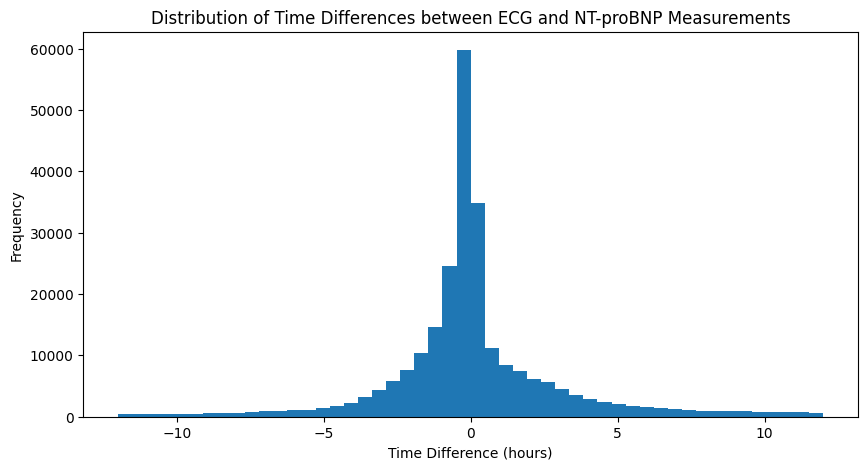

In [96]:
# plot the distribution of time differences
plt.figure(figsize=(10, 5))
merged_filtered['time_delta_hours'] = merged_filtered['time_diff'].dt.total_seconds() / 3600
merged_filtered['time_delta_hours'].dropna().hist(bins=50)
plt.title('Distribution of Time Differences between ECG and NT-proBNP Measurements')
plt.xlabel('Time Difference (hours)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

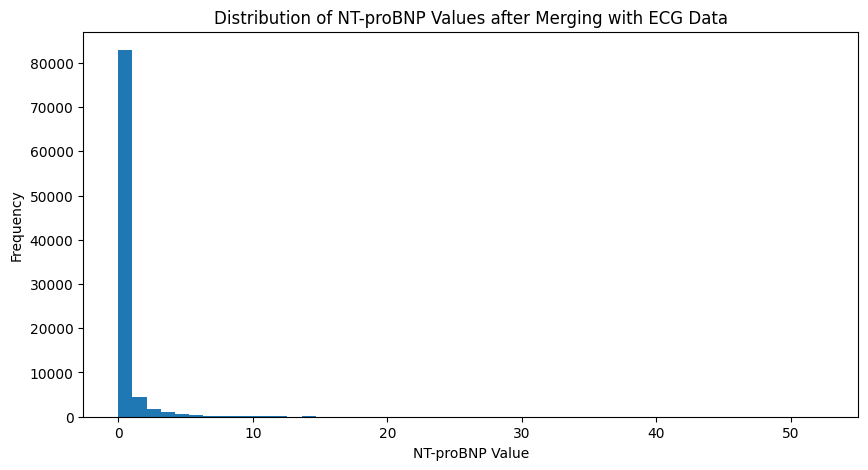

In [98]:
# plot the distribution of the ntpobnp values
plt.figure(figsize=(10, 5))
merged_filtered['valuenum'].dropna().hist(bins=50)
plt.title('Distribution of NT-proBNP Values after Merging with ECG Data')
plt.xlabel('NT-proBNP Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

Total number of merged records: 248932
Number of unique patients in merged records: 73067
Patient with most entries: 12298456 with 194 entries
Filtered records for patient with most entries: 6
Filtered records head:        subject_id  study_id            ecg_time           charttime  valuenum  \
24600    12298456  45649806 2117-01-19 15:26:00 2117-01-19 16:20:00      0.01   
24604    12298456  41290757 2117-01-19 21:57:00 2117-01-19 22:00:00      0.02   
24605    12298456  41594991 2117-01-20 02:47:00 2117-01-20 02:45:00      0.02   
24606    12298456  45454715 2117-01-20 05:10:00 2117-01-20 05:10:00      0.02   
28609    12298456  44037222 2117-12-15 19:34:00 2117-12-15 20:55:00      0.02   
28610    12298456  42107811 2117-12-15 20:46:00 2117-12-15 20:55:00      0.02   

                                      file_name      flag         time_diff  \
24600  files/p1229/p12298456/s45649806/45649806       NaN -1 days +23:06:00   
24604  files/p1229/p12298456/s41290757/41290757  abnormal 

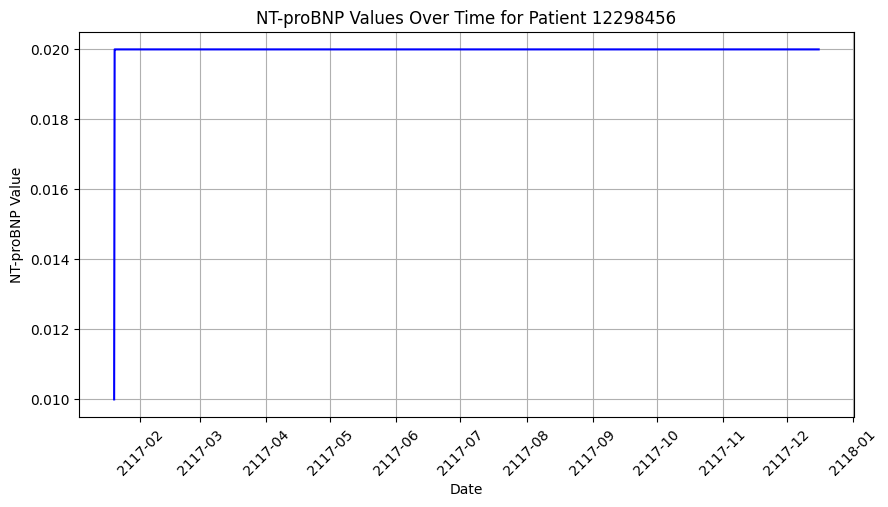

In [105]:
print("Total number of merged records:", len(merged_filtered))
print("Number of unique patients in merged records:", merged_filtered['subject_id'].nunique())

# patient with most entries
most_entries_patient = merged_filtered['subject_id'].value_counts().idxmax()
most_entries_count = merged_filtered['subject_id'].value_counts().max()
print(f"Patient with most entries: {most_entries_patient} with {most_entries_count} entries")

merged_filtered_lol = merged_filtered[(merged_filtered['subject_id'] == most_entries_patient) & (merged_filtered['charttime'] >= pd.Timestamp('2117-01-01')) & (merged_filtered['charttime'] <= pd.Timestamp('2118-01-01'))]
merged_filtered_lol = merged_filtered_lol.dropna(subset=['valuenum', 'charttime'])
print("Filtered records for patient with most entries:", len(merged_filtered_lol))
print("Filtered records head:"  , merged_filtered_lol.head(n=100))
# plot most_entries_count 
values = merged_filtered_lol[merged_filtered_lol['subject_id'] == most_entries_patient]['valuenum']
dates = merged_filtered_lol[merged_filtered_lol['subject_id'] == most_entries_patient]['charttime']

plt.figure(figsize=(10, 5))
plt.plot(dates, values, linestyle='-', color='blue')
plt.title(f'NT-proBNP Values Over Time for Patient {most_entries_patient}')
plt.xlabel('Date')
plt.ylabel('NT-proBNP Value')
plt.xticks(rotation=45)
plt.grid()


/tmp/ipykernel_85904/2597605950.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['log_valuenum'] = np.log(merged_filtered['valuenum'].replace(0, np.nan))  # Avoid log(0)


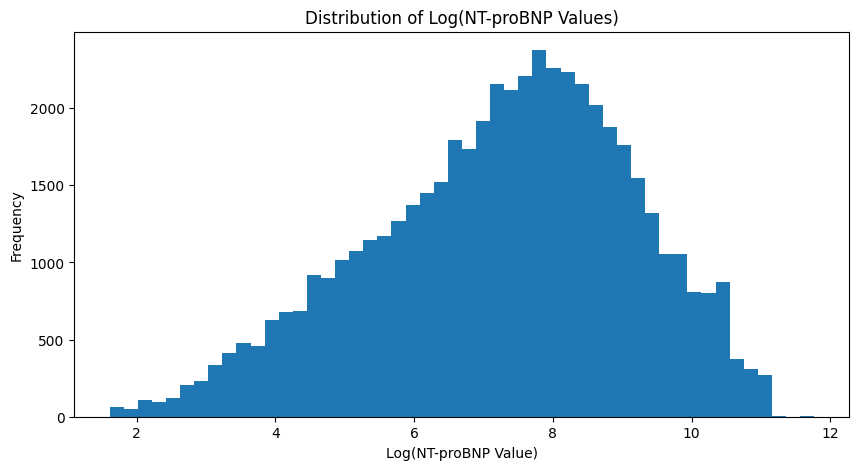

In [82]:
# logarithm of the values
merged_filtered['log_valuenum'] = np.log(merged_filtered['valuenum'].replace(0, np.nan))  # Avoid log(0)
plt.figure(figsize=(10, 5))
merged_filtered['log_valuenum'].dropna().hist(bins=50)
plt.title('Distribution of Log(NT-proBNP Values)')
plt.xlabel('Log(NT-proBNP Value)')
plt.ylabel('Frequency')
plt.grid()
plt.show()  